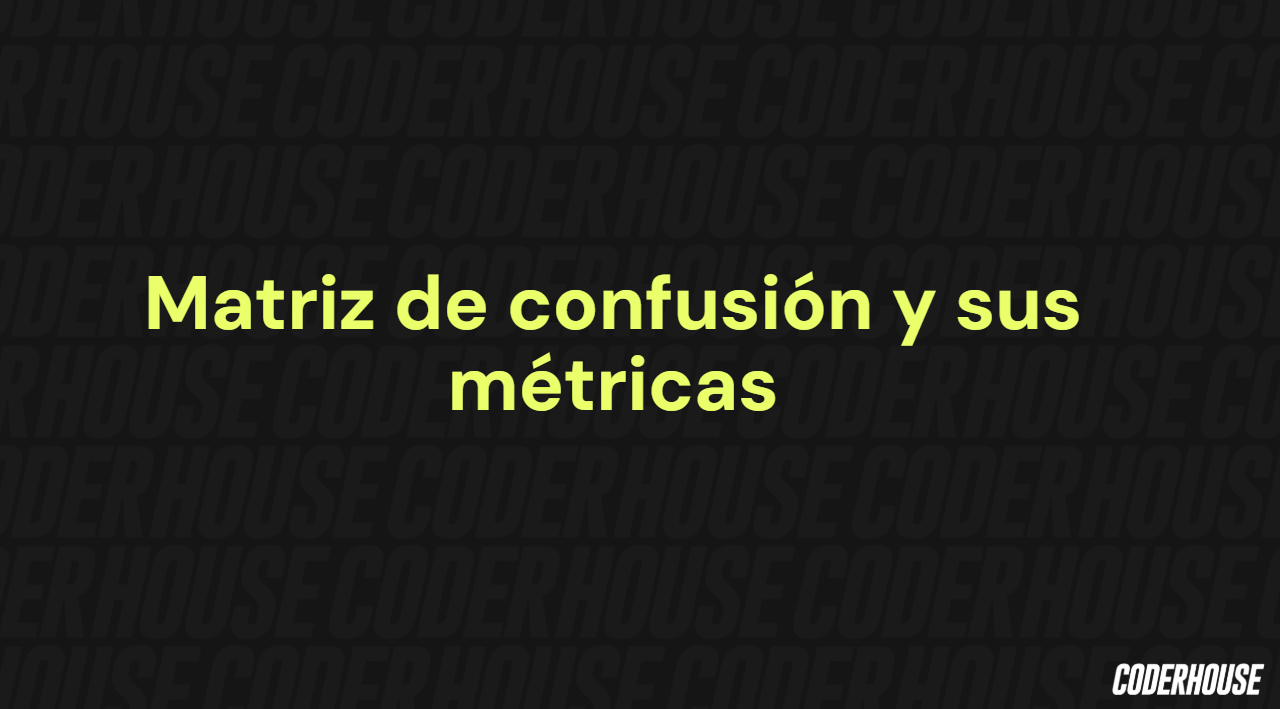

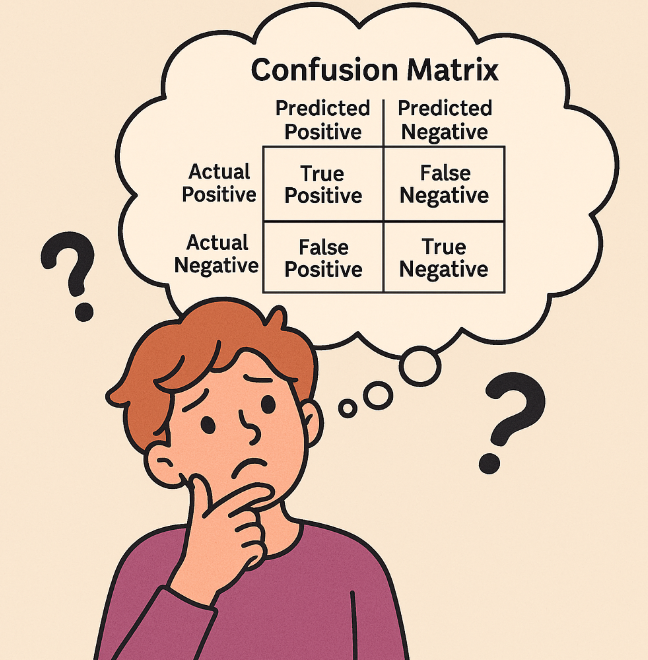

# ¿Qué es la Matriz de Confusión?
# Es una herramienta que se usa para evaluar el rendimiento de un modelo de clasificación. Compara los valores predichos por el modelo con los valores reales (etiquetas verdaderas).



# ESTRUCTURA

|                       | **Predicho Positivo (+)** | **Predicho Negativo (−)** |
| --------------------- | ------------------------- | ------------------------- |
| **Real Positivo (+)** | **TP (True Positive)**    | **FN (False Negative)**   |
| **Real Negativo (−)** | **FP (False Positive)**   | **TN (True Negative)**    |


# ¿Qué significa cada celda?


TP (Verdadero Positivo): El modelo predijo "positivo" y en realidad es positivo.

TN (Verdadero Negativo): El modelo predijo "negativo" y en realidad es negativo.

FP (Falso Positivo / Error Tipo I): El modelo predijo "positivo" pero en realidad es negativo (Ej: predecir embarazo en un hombre).

FN (Falso Negativo / Error Tipo II): El modelo predijo "negativo" pero en realidad es positivo (Ej: no predecir embarazo en una mujer embarazada).

# Métricas derivadas de la matriz


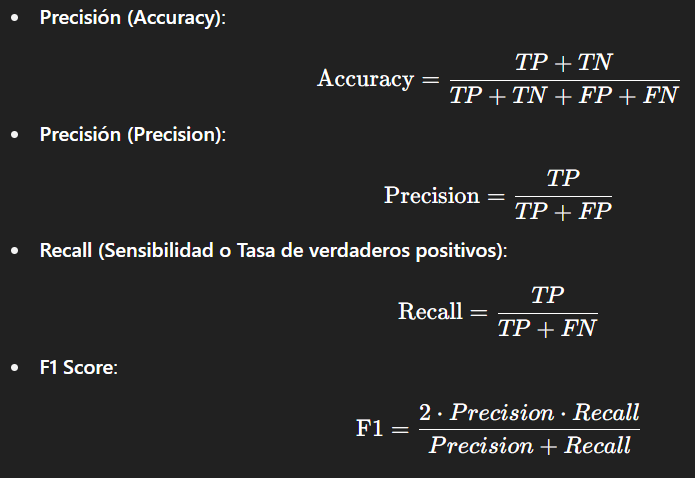

- Accuracy: mide el porcentaje de predicciones correctas sobre el total de casos.

- Precision: mide cuántos de los positivos predichos realmente lo son.

- Recall (Sensibilidad): mide cuántos de los positivos reales fueron correctamente identificados.

- F1 Score: balance entre precisión y recall, útil cuando hay clases desbalanceadas.

F1 SCORE

Supongamos que el modelo de clasificación arrojó:
Precision = 0.75
Recall = 0.60

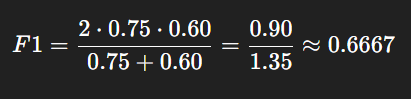

El F1 Score es aproximadamente 0.67, lo que indica un balance moderado entre precisión y recall. No es perfecto, pero está bastante bien si las clases están desbalanceadas.


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Valores reales y predichos
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]  # Clase real
y_pred = [1, 0, 1, 0, 0, 1, 1, 0, 0, 0]  # Clase predicha

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
print("Matriz de Confusión:")
print(cm)

# Métricas
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\nPrecisión (Precision): {precision:.2f}")
print(f"Recall (Sensibilidad): {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Matriz de Confusión:
[[4 1]
 [2 3]]

Precisión (Precision): 0.75
Recall (Sensibilidad): 0.60
F1 Score: 0.67


Verdaderos Positivos (TP): 3 → predijo 1 cuando era 1.

Falsos Positivos (FP): 1 → predijo 1 cuando era 0.

Falsos Negativos (FN): 2 → predijo 0 cuando era 1.

Verdaderos Negativos (TN): 4 → predijo 0 cuando era 0.

# ¿Cómo saber si las clases están desbalanceadas?





In [ ]:
#CONTANDO LAS CLASES

import pandas as pd

df = pd.DataFrame({'y': [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]})
print(df['y'].value_counts())


y
1    5
0    5
Name: count, dtype: int64


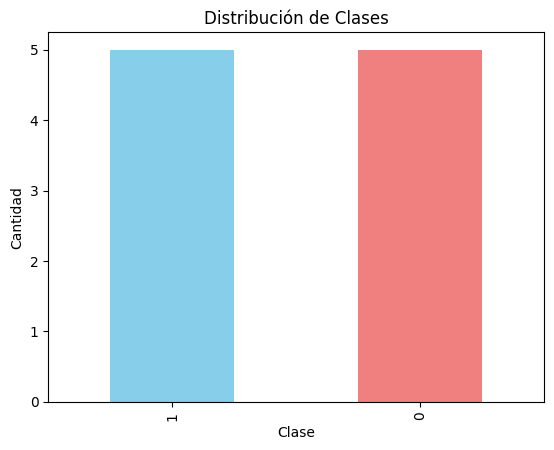

In [ ]:
#VISUALIZANDO

import matplotlib.pyplot as plt
df['y'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title("Distribución de Clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()


# Regla general para considerar que hay desbalance

| Proporción clase minoritaria | ¿Está desbalanceado? |
| ---------------------------- | -------------------- |
| 40%-60%                      | ❌ No (balanceado)    |
| 30%-70%                      | ⚠️ Leve desbalance   |
| < 20%-80%                    | ✅ Desbalanceado      |
| < 10%-90%                    | 🚨 Muy desbalanceado |


# Ejemplo real:


- Si en un dataset de fraudes bancarios tenés:

9.800 operaciones normales

200 operaciones fraudulentas

➡️ La clase fraudulenta representa solo el 2% del total.
Eso es un fuerte desbalance, y no te conviene usar Accuracy como métrica principal.


| Objetivo del negocio                                                 | Métrica clave         |
| -------------------------------------------------------------------- | --------------------- |
| Prefiero **detectar todos los fraudes**, aunque me equivoque a veces | Recall (Sensibilidad) |
| Prefiero **no acusar inocentes** si no estoy muy seguro              | Precision             |
| Quiero equilibrio entre ambos                                        | F1 Score              |
| Quiero comparar modelos globalmente                                  | AUC-ROC               |


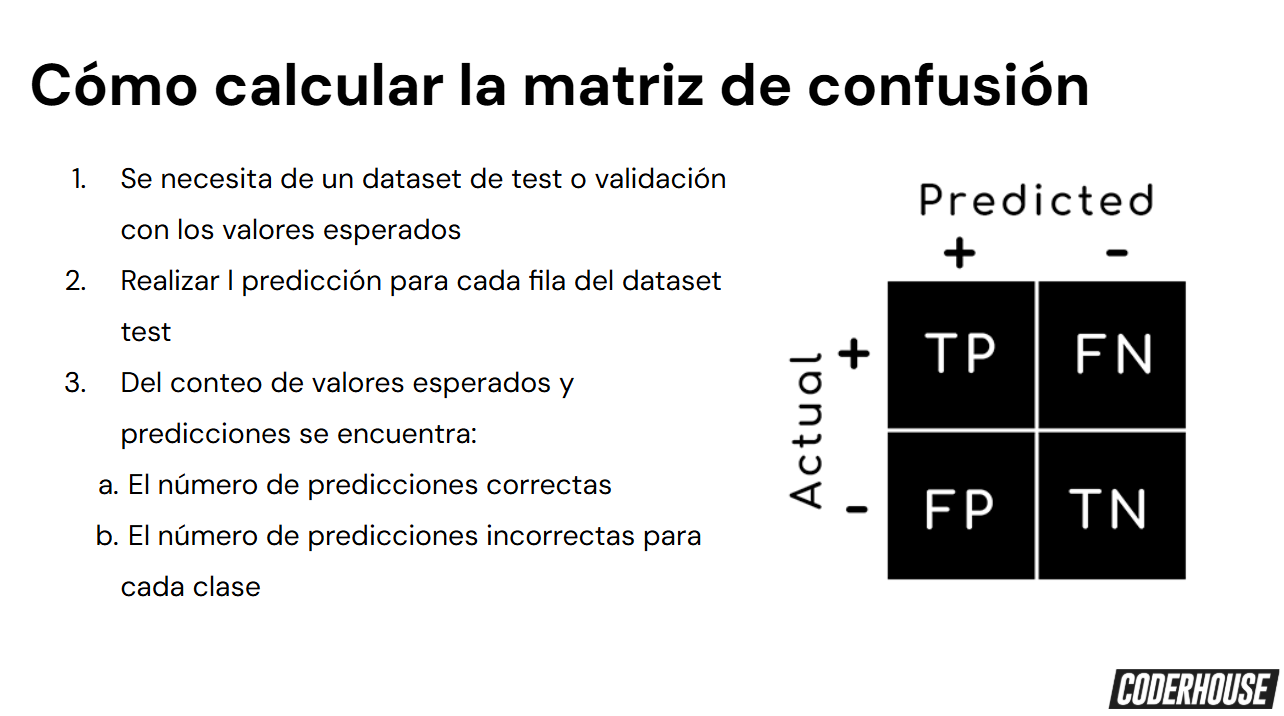

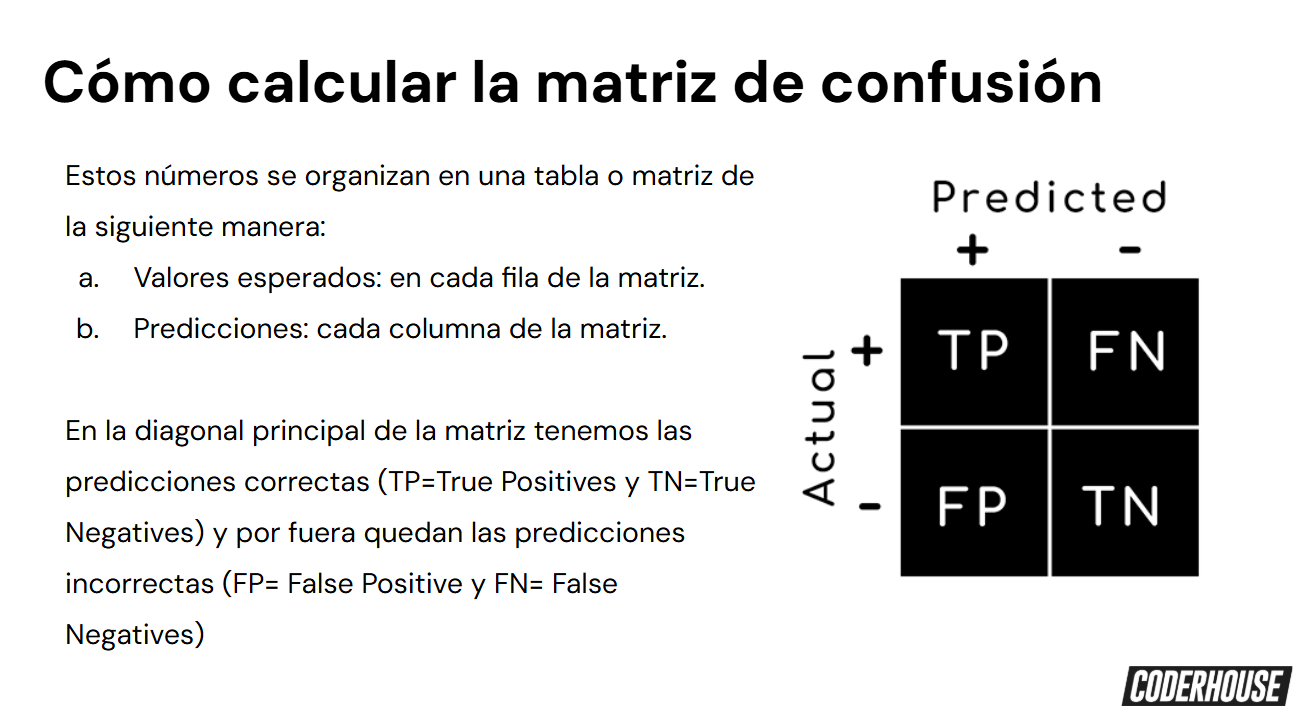

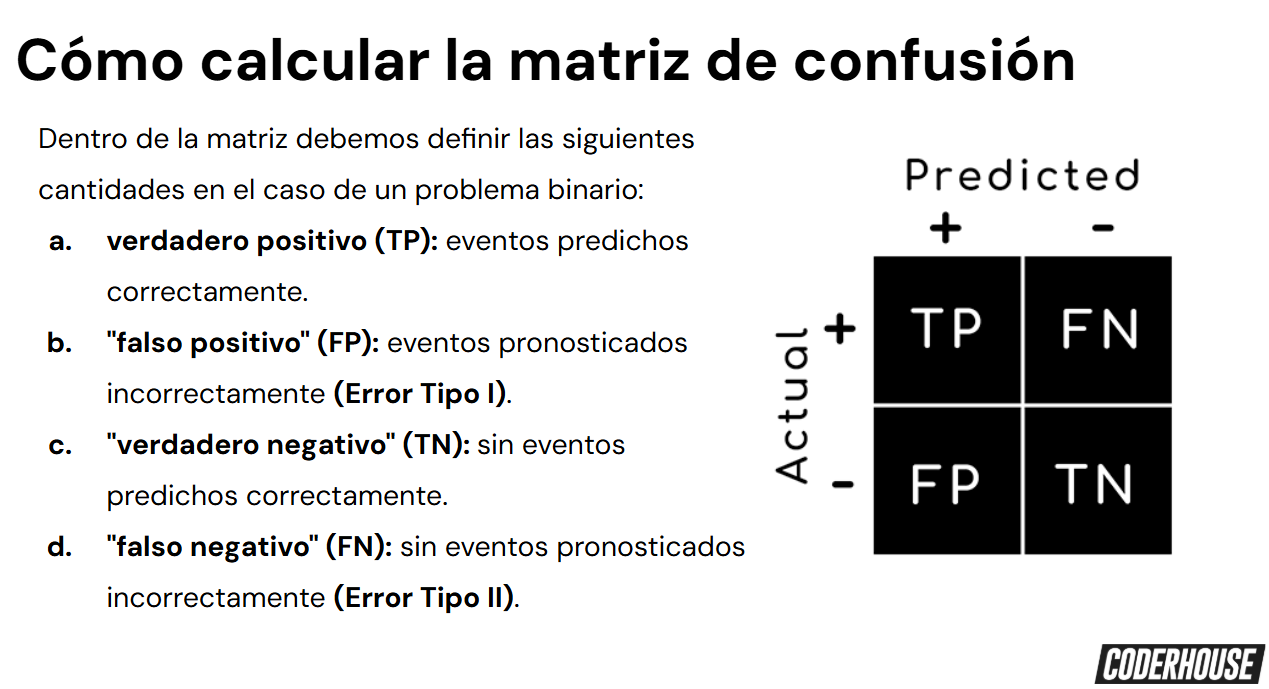

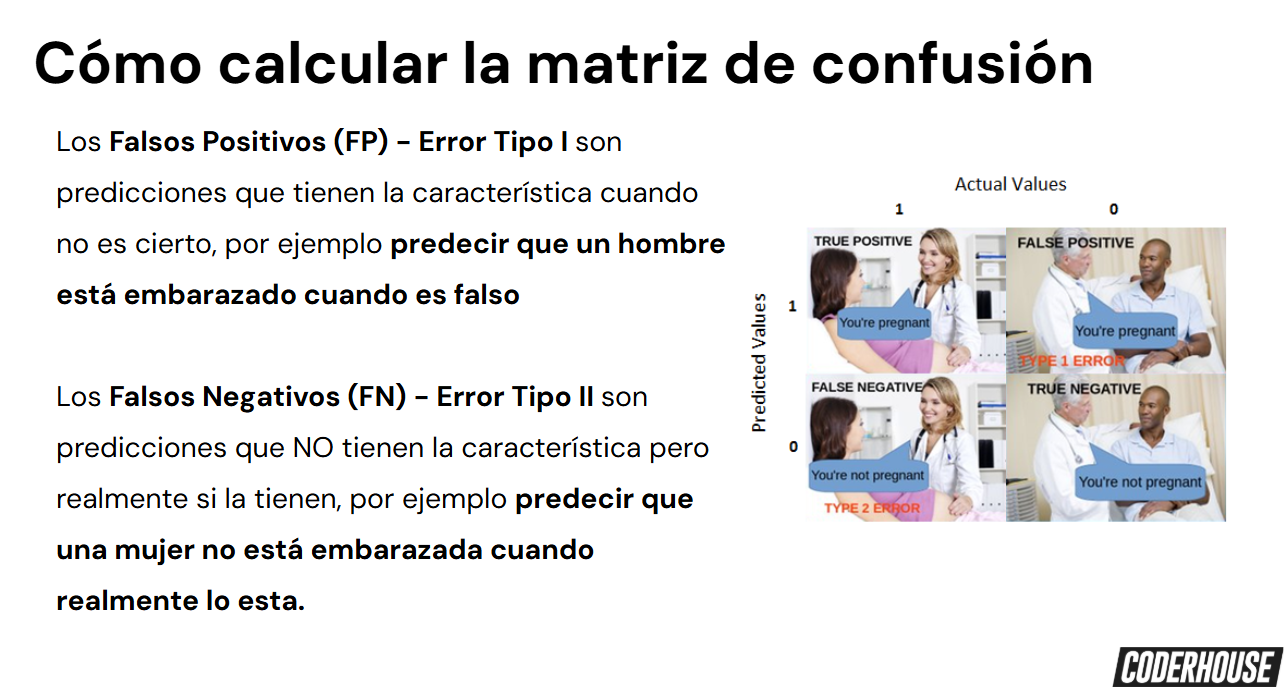

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Valores reales (spam = 1, no spam = 0)
y_true = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0]

# Valores predichos por el modelo
y_pred = [1, 0, 0, 1, 1, 0, 1, 0, 0, 1]


In [ ]:
# Creamos la matriz de confusión
matriz = confusion_matrix(y_true, y_pred)

# Mostramos en un DataFrame bonito
df_matriz = pd.DataFrame(matriz,
                         index=["Real: No Spam (0)", "Real: Spam (1)"],
                         columns=["Predicho: No Spam (0)", "Predicho: Spam (1)"])

print(df_matriz)


                   Predicho: No Spam (0)  Predicho: Spam (1)
Real: No Spam (0)                      3                   2
Real: Spam (1)                         2                   3


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precisión: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.60
Precisión: 0.60
Recall: 0.60
F1 Score: 0.60


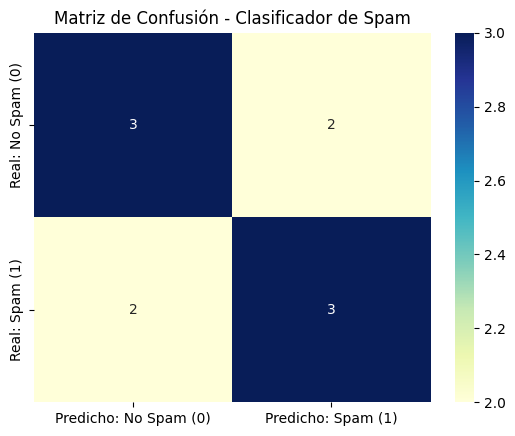

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_matriz, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Matriz de Confusión - Clasificador de Spam")
plt.show()


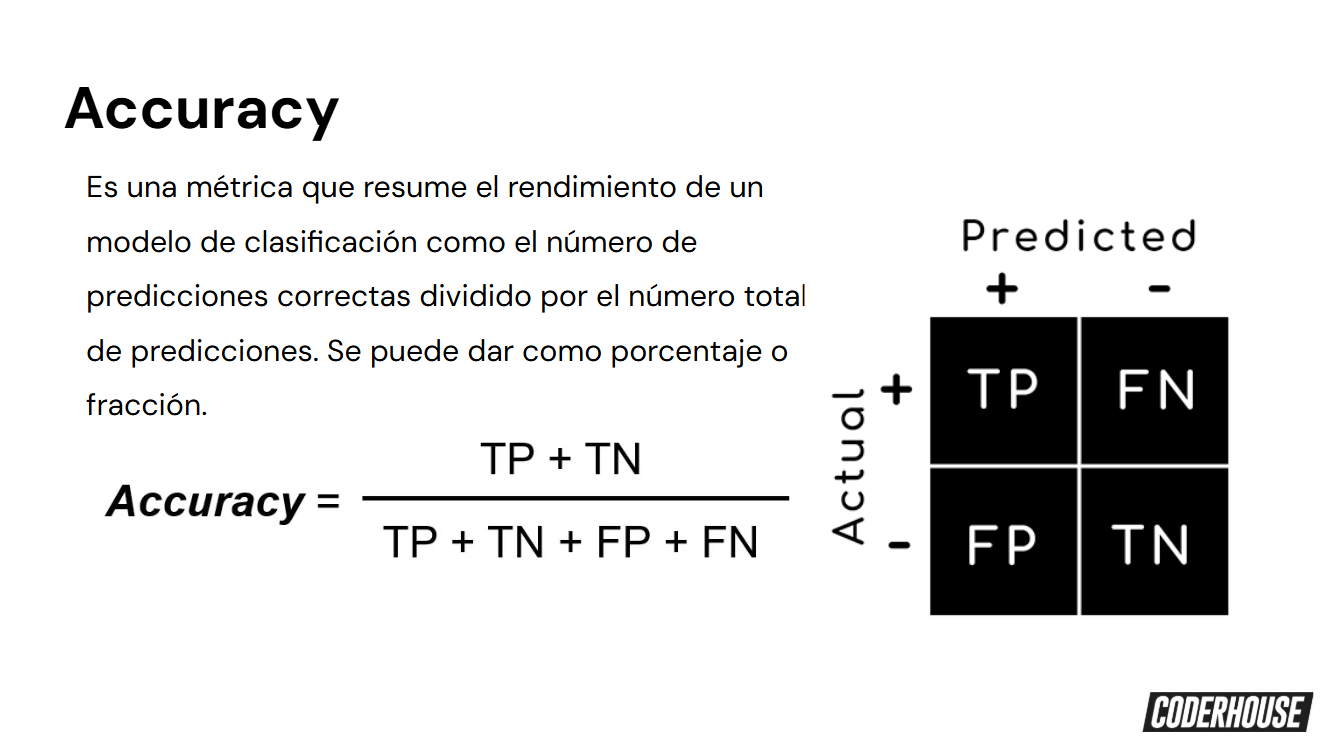

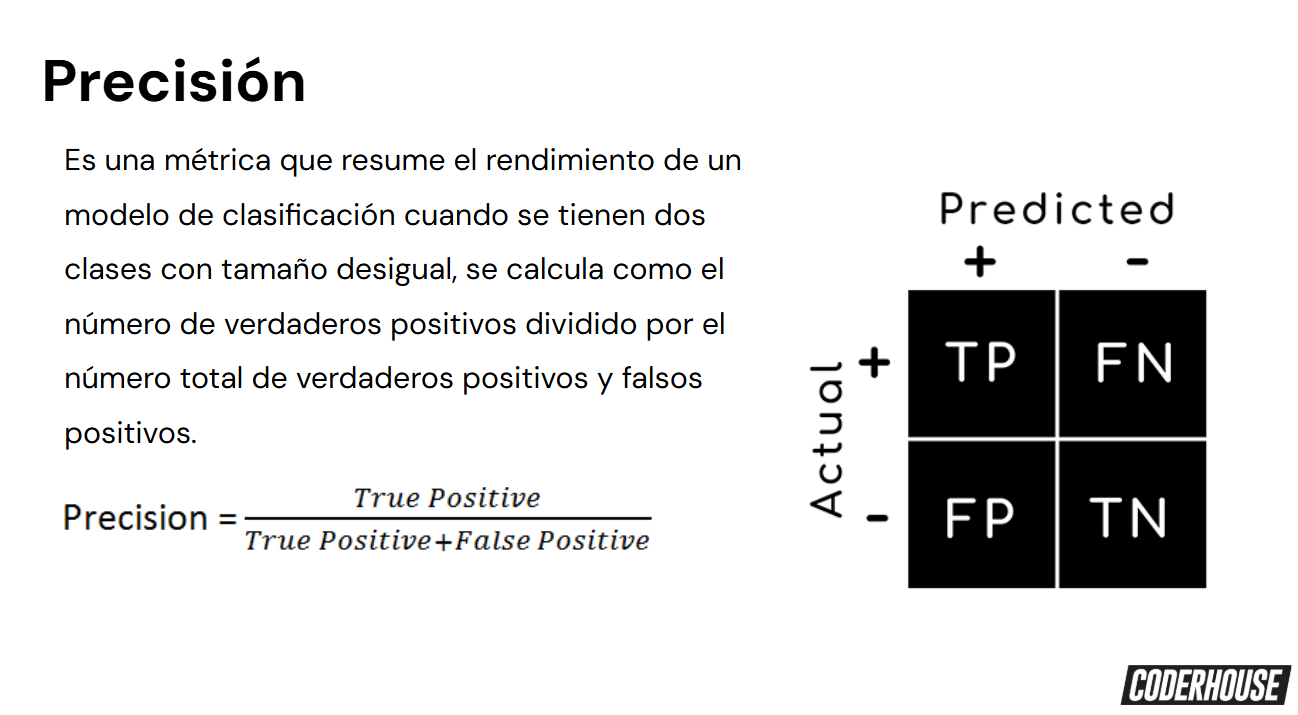

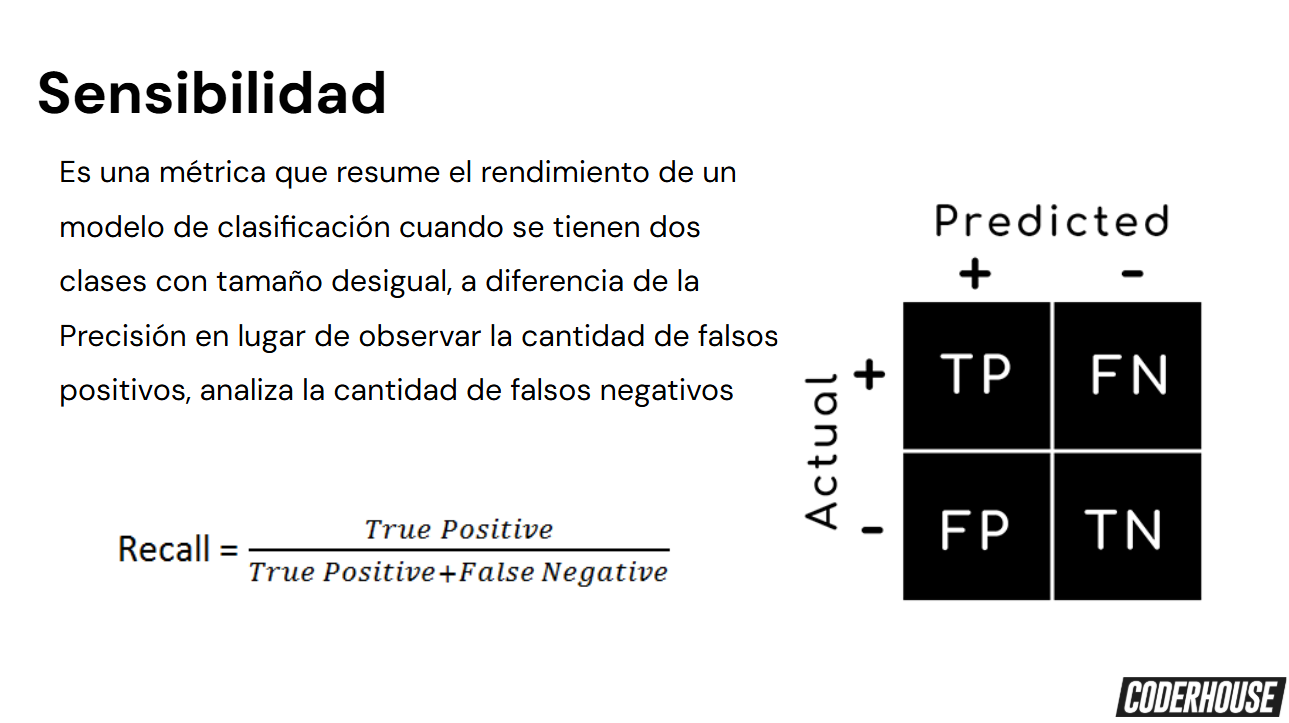

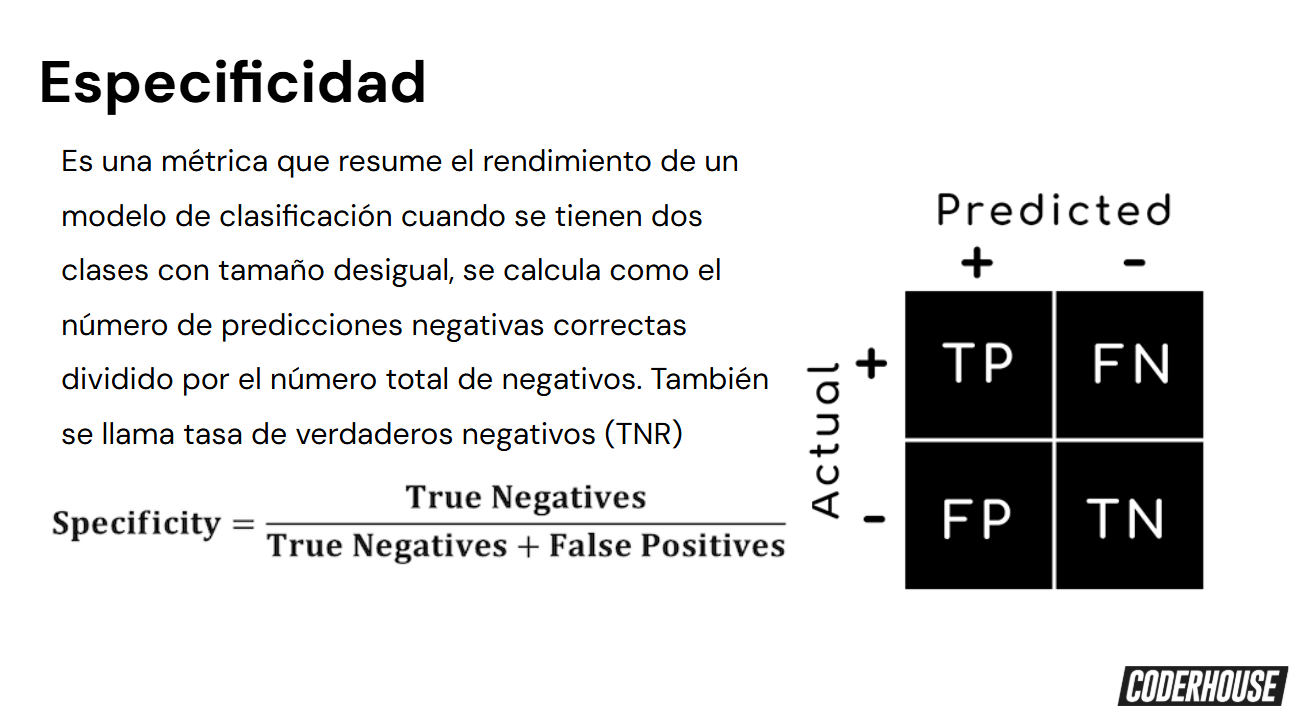

La especificidad mide qué tan bien el modelo detecta correctamente los casos negativos. Es decir, de todos los casos que eran negativos (clase 0, por ejemplo), ¿cuántos el modelo predijo correctamente como negativos?


Es fundamental cuando:

Querés evitar falsos positivos.

Estás en contextos donde un diagnóstico positivo incorrecto puede ser grave o costoso.
Ejemplo: diagnóstico de cáncer, sistemas anti-fraude bancario (no querés bloquear transacciones legítimas por error).


# comparamos recall con especificidad

| Métrica                         | Fórmula        | ¿Qué evalúa?                                  |
| ------------------------------- | -------------- | --------------------------------------------- |
| **Recall** (Sensibilidad)       | TP / (TP + FN) | Qué tan bien detecta los **positivos reales** |
| **Specificity** (Especificidad) | TN / (TN + FP) | Qué tan bien detecta los **negativos reales** |

__________
* Recall se enfoca en la clase positiva → útil si lo importante es no dejar pasar un caso positivo (ej. detectar fraudes, enfermedades, etc.).

* Specificity se enfoca en la clase negativa → útil si lo importante es no tener falsos positivos (ej. no acusar inocentes, no rechazar clientes buenos).


# Ambas forman parte del balance global del modelo y se usan juntas para métricas como AUC-ROC.

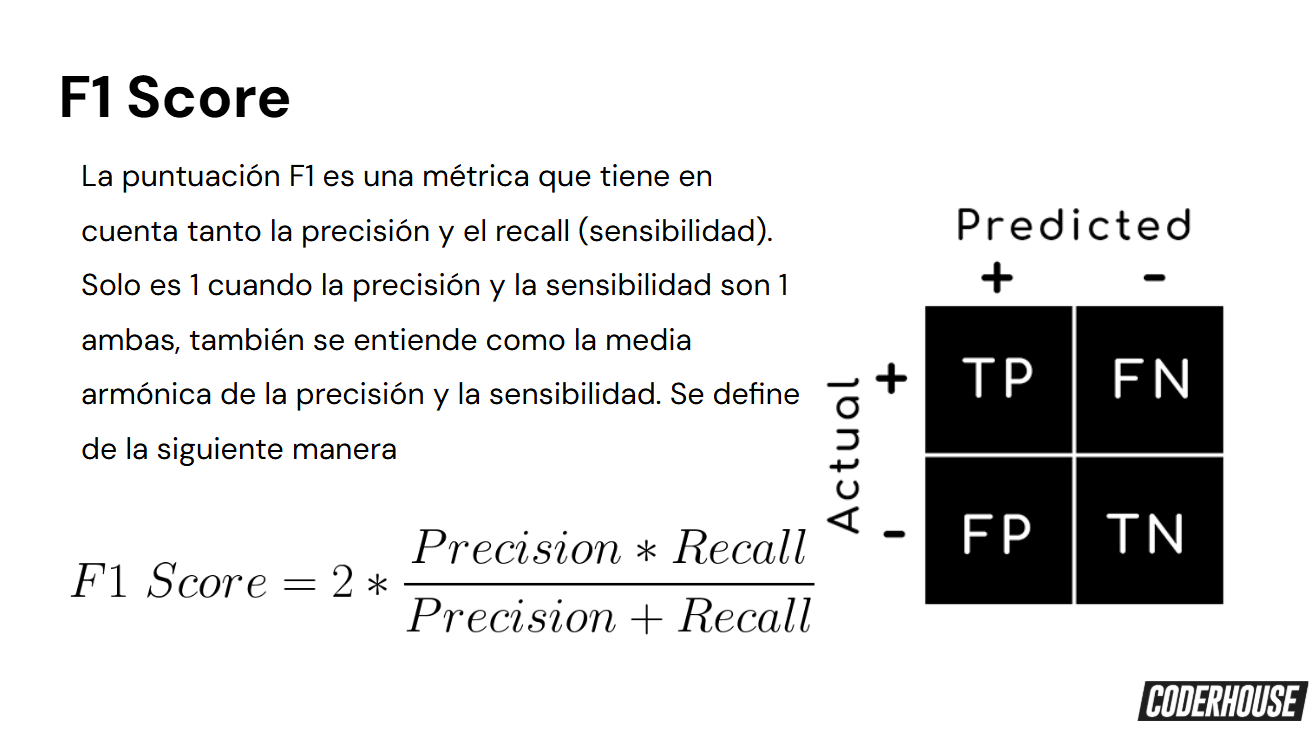

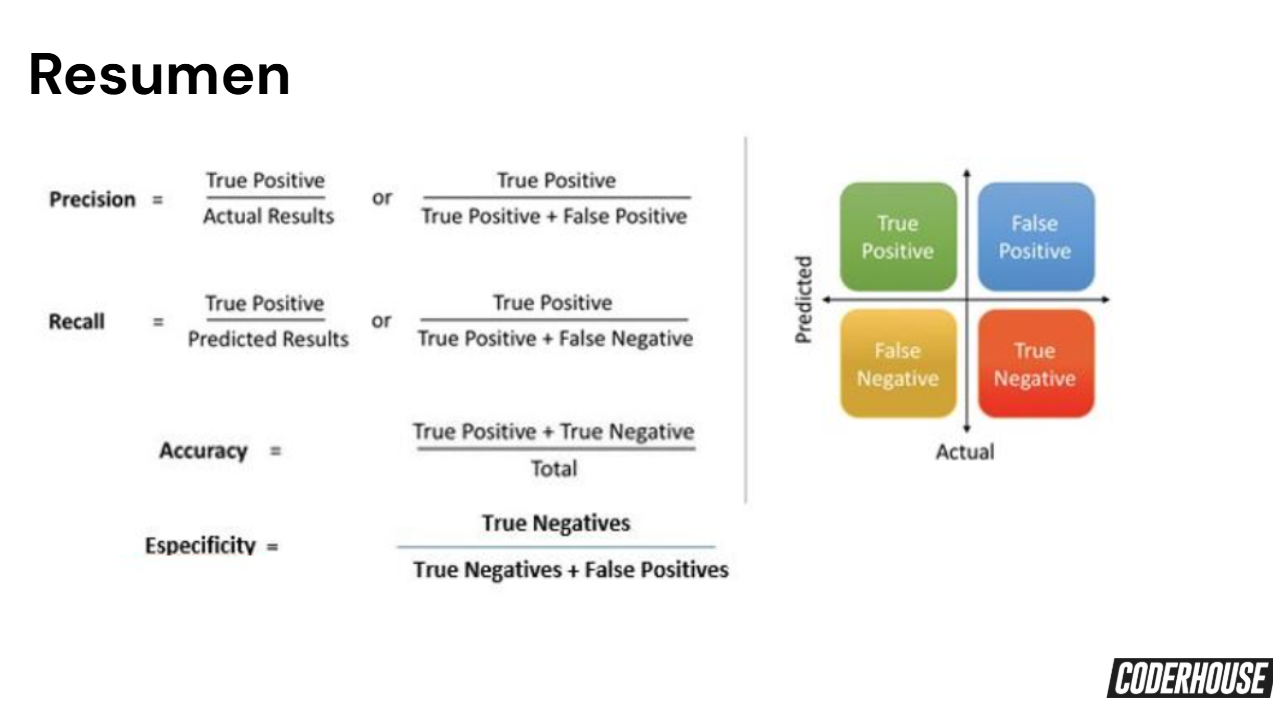

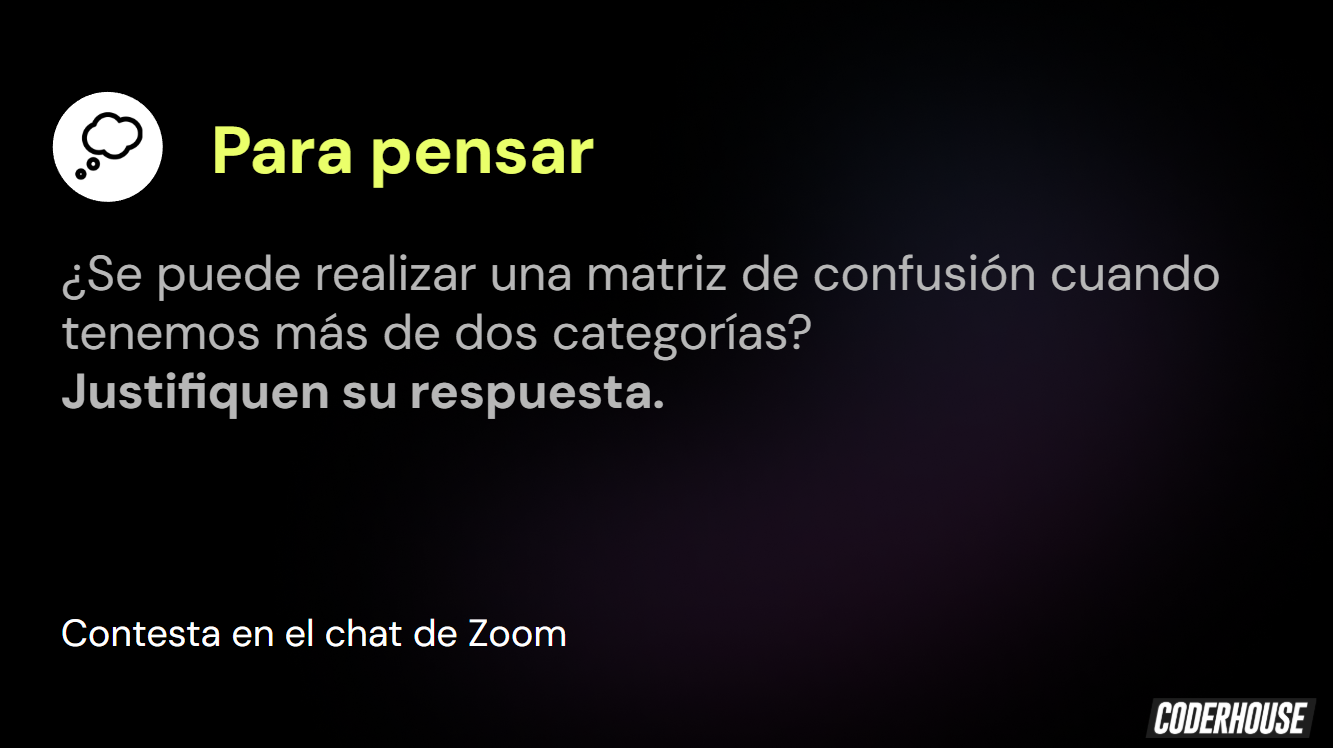

Sí.La matriz de confusión no se limita a problemas binarios. También puede aplicarse a problemas de clasificación multiclase, es decir, cuando hay más de dos clases posibles.

En un problema binario la matriz es de 2×2, porque hay dos clases (por ejemplo, spam vs. no spam).
Pero si tenemos un problema con 3 clases, como por ejemplo:

🐶 Clase A: Perros

🐱 Clase B: Gatos

🐭 Clase C: Ratones

Entonces, la matriz de confusión será de 3×3, y cada celda [i, j] indica cuántos elementos de la clase real i fueron predichos como clase j.

**En resumen:**

Sí se puede hacer una matriz de confusión con más de dos categorías. En ese caso, la matriz es cuadrada (n×n), siendo n el número de clases. Nos permite ver cuántas veces cada clase fue correctamente clasificada o confundida con otra.


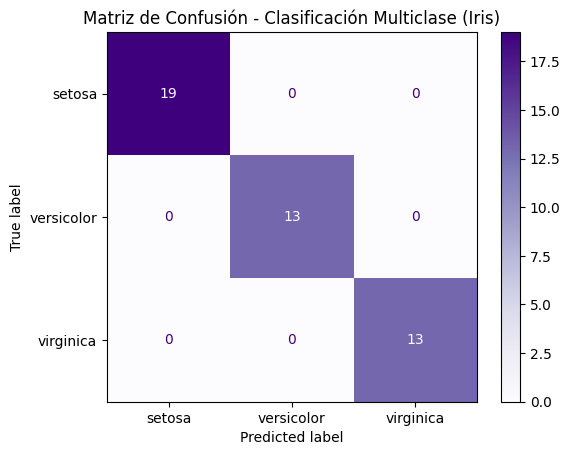


📋 Reporte de métricas por clase:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names  # ['setosa', 'versicolor', 'virginica']

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelo de regresión logística
modelo = LogisticRegression(max_iter=200)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Purples')
plt.title("Matriz de Confusión - Clasificación Multiclase (Iris)")
plt.show()

# Reporte de clasificación por clase
print("\n📋 Reporte de métricas por clase:\n")
print(classification_report(y_test, y_pred, target_names=target_names))


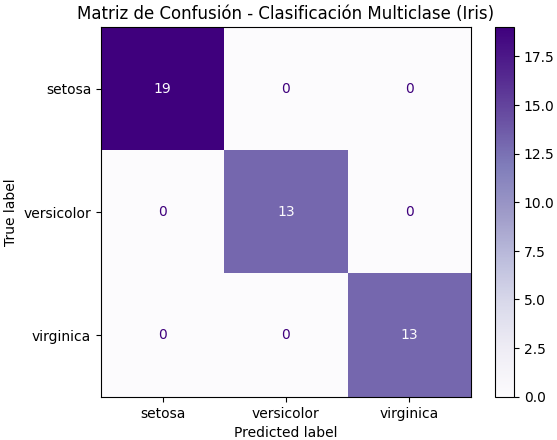


**Esta matriz evalúa un modelo que predice la clase de una flor del dataset Iris, que tiene tres clases:**

setosa

versicolor

virginica

Interpretación

|                      | Predicho: setosa | Predicho: versicolor | Predicho: virginica |
| -------------------- | ---------------- | -------------------- | ------------------- |
| **Real: setosa**     | **19**           | 0                    | 0                   |
| **Real: versicolor** | 0                | **13**               | 0                   |
| **Real: virginica**  | 0                | 0                    | **13**              |


Diagonal principal (↘):

Son los aciertos (predicción correcta).

El modelo acertó 19 veces que era setosa, 13 veces que era versicolor, y 13 veces que era virginica.

Fuera de la diagonal:

Son los errores.

En este caso, no hay errores: ¡todas las predicciones coinciden con la clase real!

El modelo clasificó perfectamente las 45 muestras de prueba.

Cada fila representa lo que realmente era la flor. Cada columna representa lo que predijo el modelo. Si el modelo se equivoca, ese error aparece fuera de la diagonal. Como acá toda la información está en la diagonal, significa que el modelo no se equivocó: predijo perfectamente todas las clases

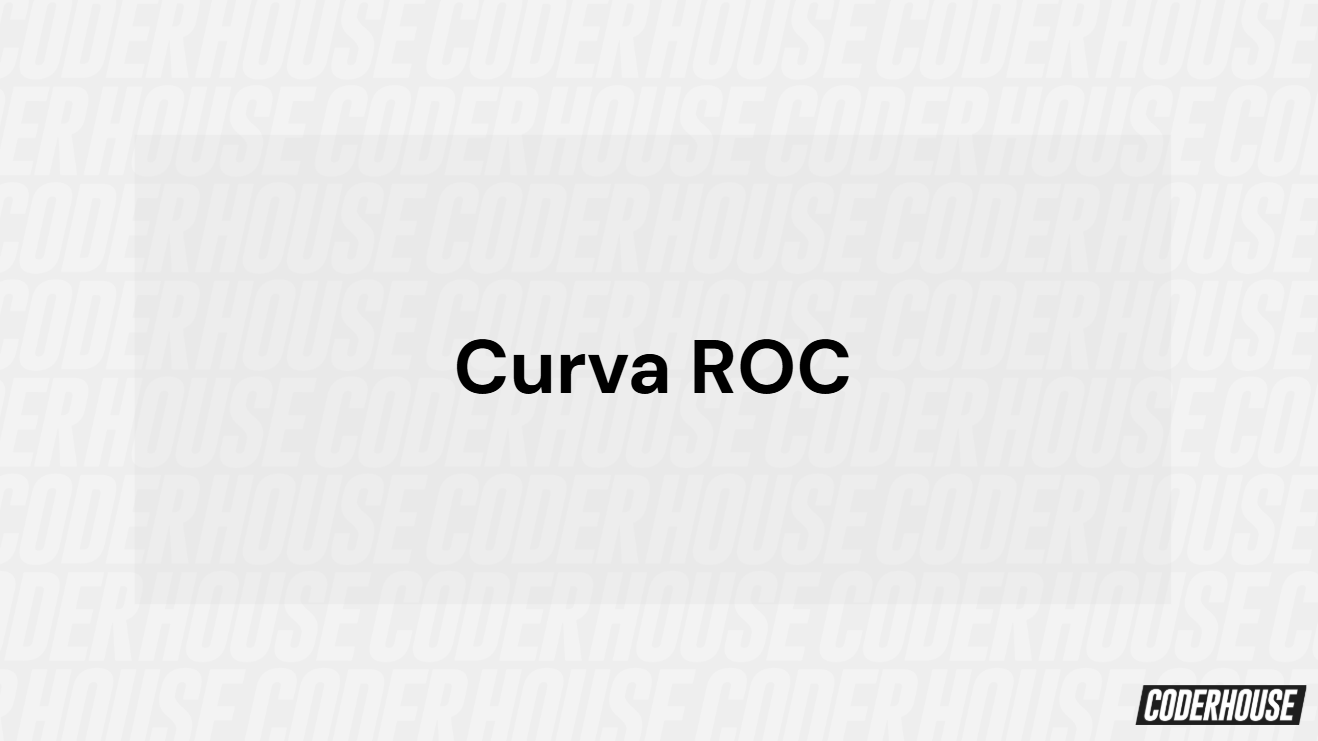

¿Qué es la Curva ROC?
La Curva ROC (Receiver Operating Characteristic) es una herramienta visual que se utiliza para evaluar modelos de clasificación binaria. Nos muestra qué tan bien es capaz el modelo de distinguir entre las dos clases (por ejemplo: positivo vs. negativo, spam vs. no spam, enfermo vs. sano, etc.).

📊 ¿Qué representa?
La curva ROC es un gráfico en dos dimensiones:

Eje X: Tasa de Falsos Positivos (FPR) = FP / (FP + TN)
→ ¿Cuántos negativos se predijeron incorrectamente como positivos?

Eje Y: Tasa de Verdaderos Positivos (TPR o Recall) = TP / (TP + FN)
→ ¿Cuántos positivos se detectaron correctamente?

🎯 ¿Cómo se genera la curva?
La curva se traza al variar el umbral de decisión del modelo. Por ejemplo, un modelo puede dar una probabilidad de que un caso sea positivo. Según dónde pongamos el umbral (threshold) —por ejemplo, 0.5—, el modelo clasifica como positivo o negativo. Al mover ese umbral de 0 a 1, se genera la curva ROC.

✅ ¿Qué nos dice?
Una curva más cercana al vértice superior izquierdo indica mejor desempeño.

Una línea diagonal indica un modelo sin poder de discriminación (como tirar una moneda).

Se suele acompañar del AUC (Area Under the Curve):

AUC = 1 → modelo perfecto

AUC = 0.5 → modelo aleatorio

AUC < 0.5 → modelo peor que azar

📌 En resumen:
La Curva ROC muestra el equilibrio entre sensibilidad (TPR) y especificidad (1 - FPR) a distintos umbrales. Es una herramienta fundamental para comparar modelos y decidir el mejor punto de corte según el contexto.



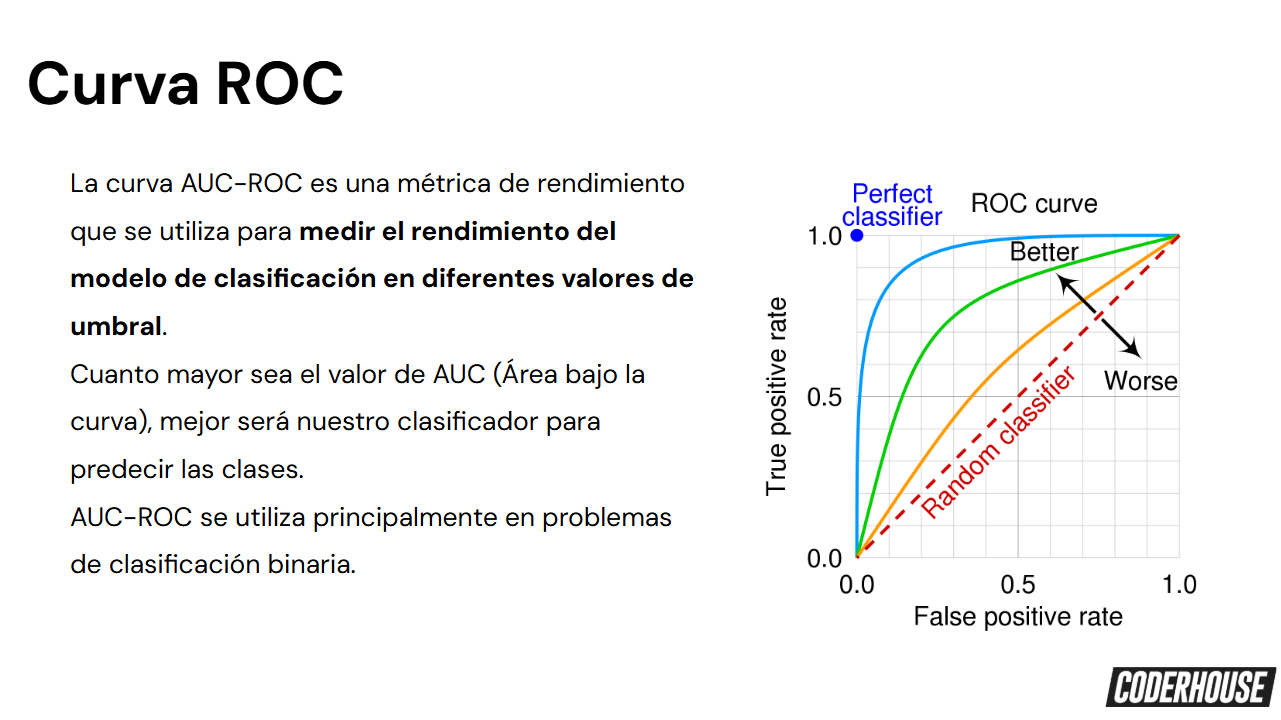

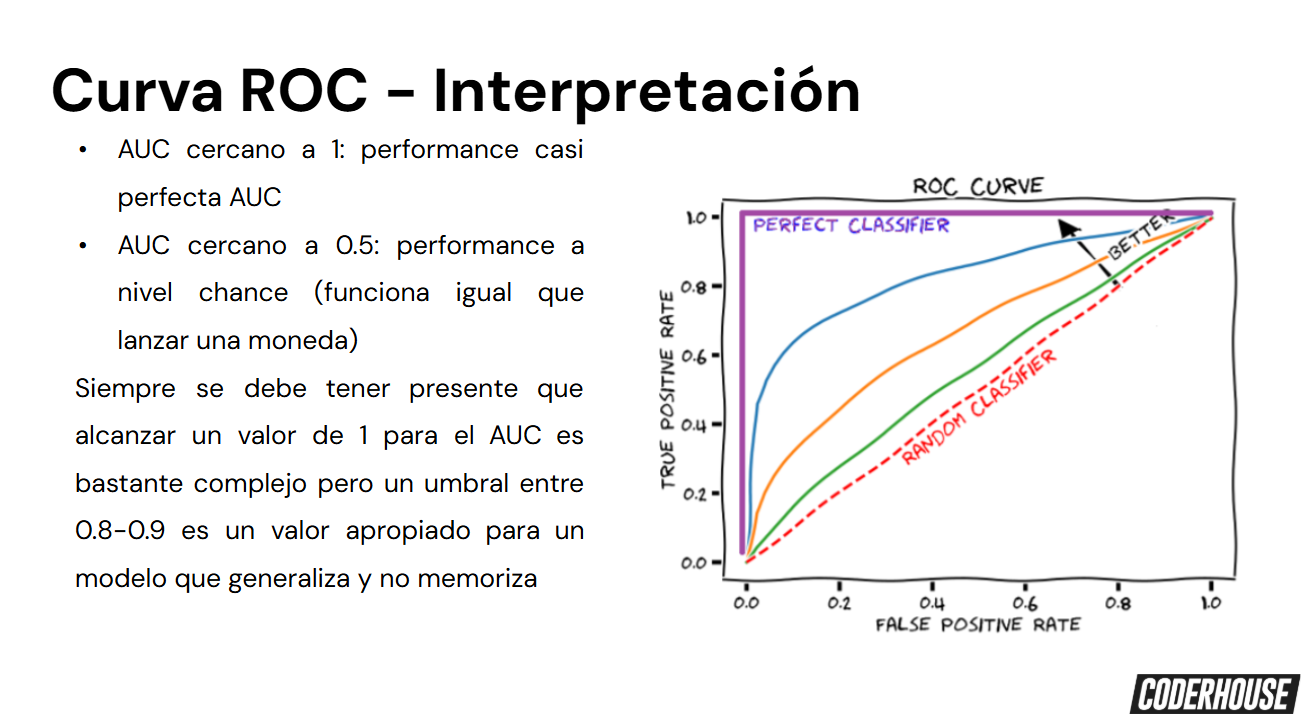

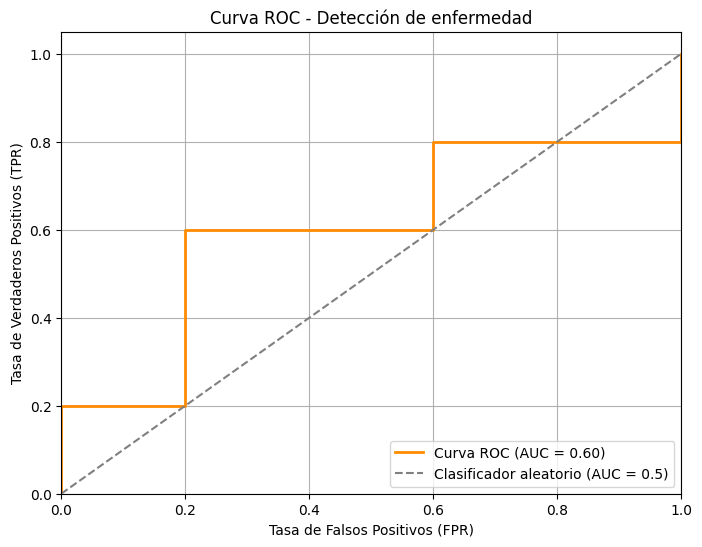

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Datos simulados: 1 = enfermo, 0 = sano
y_true = [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]  # Etiquetas reales
y_scores = [0.95, 0.90, 0.85, 0.70, 0.60, 0.55, 0.40, 0.30, 0.20, 0.10]  # Probabilidades del modelo

# Calculamos puntos para la curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Graficamos la curva
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')

# Detalles del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Detección de enfermedad')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


¿Qué estamos viendo?
El gráfico muestra dos líneas:

🟠 Curva ROC del modelo, con un AUC = 0.60

⚫ Línea diagonal gris, que representa un modelo aleatorio (AUC = 0.5)

📊 ¿Cómo se lee?
Eje X: Tasa de Falsos Positivos (FPR)
Cuántos negativos (sanos) el modelo clasificó incorrectamente como positivos (enfermos).

Eje Y: Tasa de Verdaderos Positivos (TPR o Recall)
Cuántos positivos (enfermos reales) el modelo detectó correctamente.

✅ Interpretación del AUC = 0.60
El modelo tiene una ligera capacidad de distinguir entre enfermos y sanos.

AUC = 0.60 significa que si el modelo tiene que elegir al azar entre un enfermo y un sano, hay un 60% de probabilidad de que le asigne un score más alto al enfermo.

Es mejor que azar, pero muy lejos del óptimo (que sería AUC ≈ 1.0).

📌 Conclusión técnica y didáctica

Este modelo no está completamente mal, pero necesita mejorar. Podría estar:

Subajustado (underfitting)

Mal entrenado (datos insuficientes, features pobres)

O simplemente el problema es difícil con los datos actuales

Un buen modelo realista suele tener AUC entre 0.8 y 0.9.
Una AUC entre 0.6 y 0.7, como en tu gráfico, puede considerarse aceptable en contextos difíciles (como medicina o fraude), pero se debe analizar y mejorar.



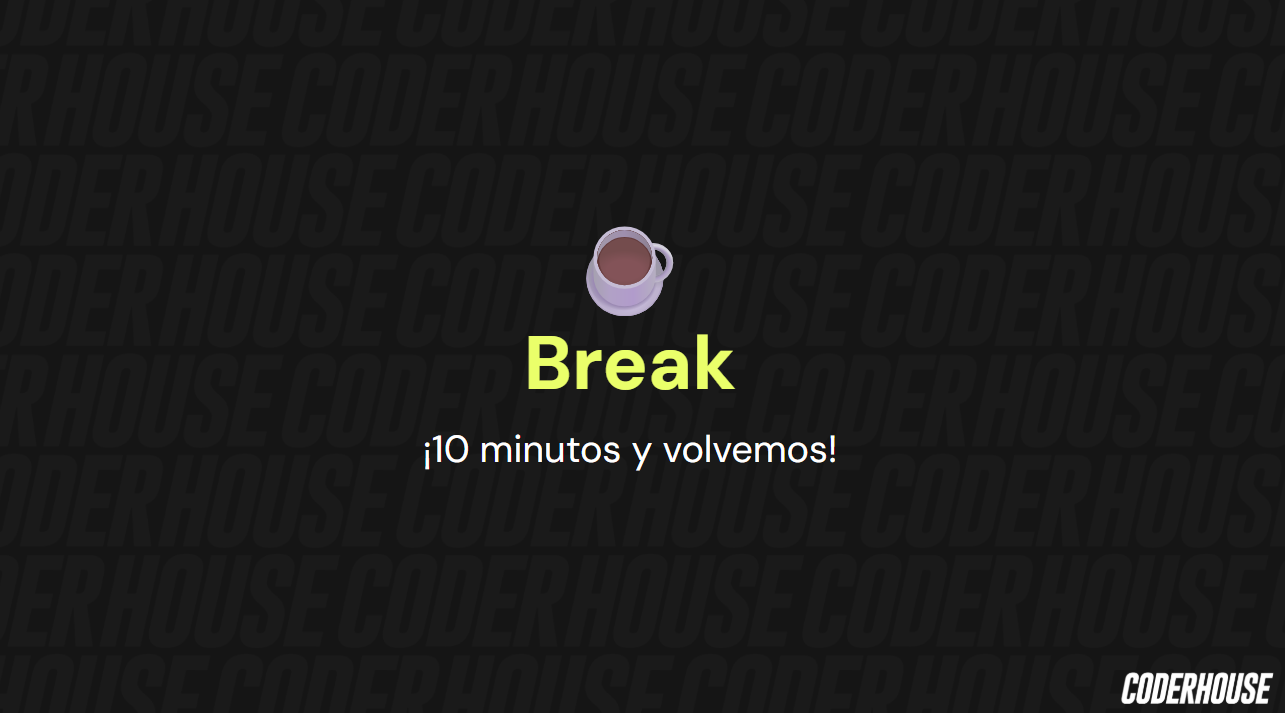

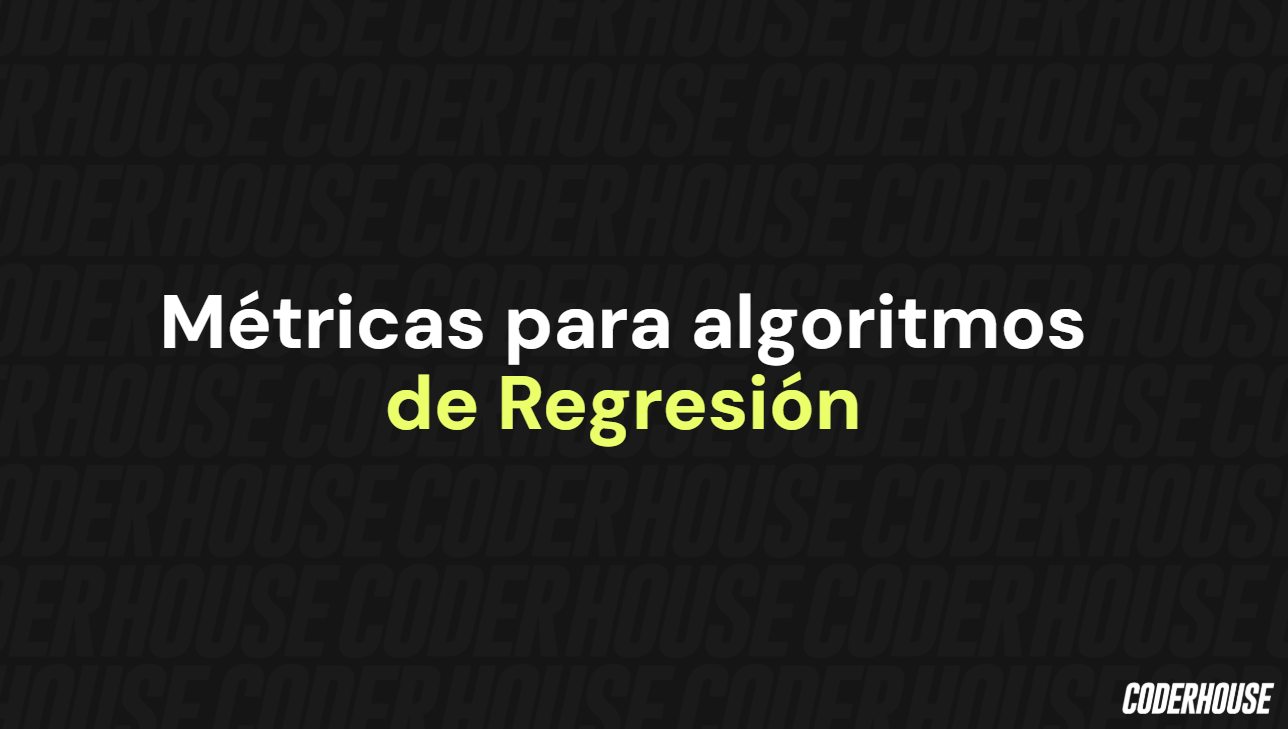

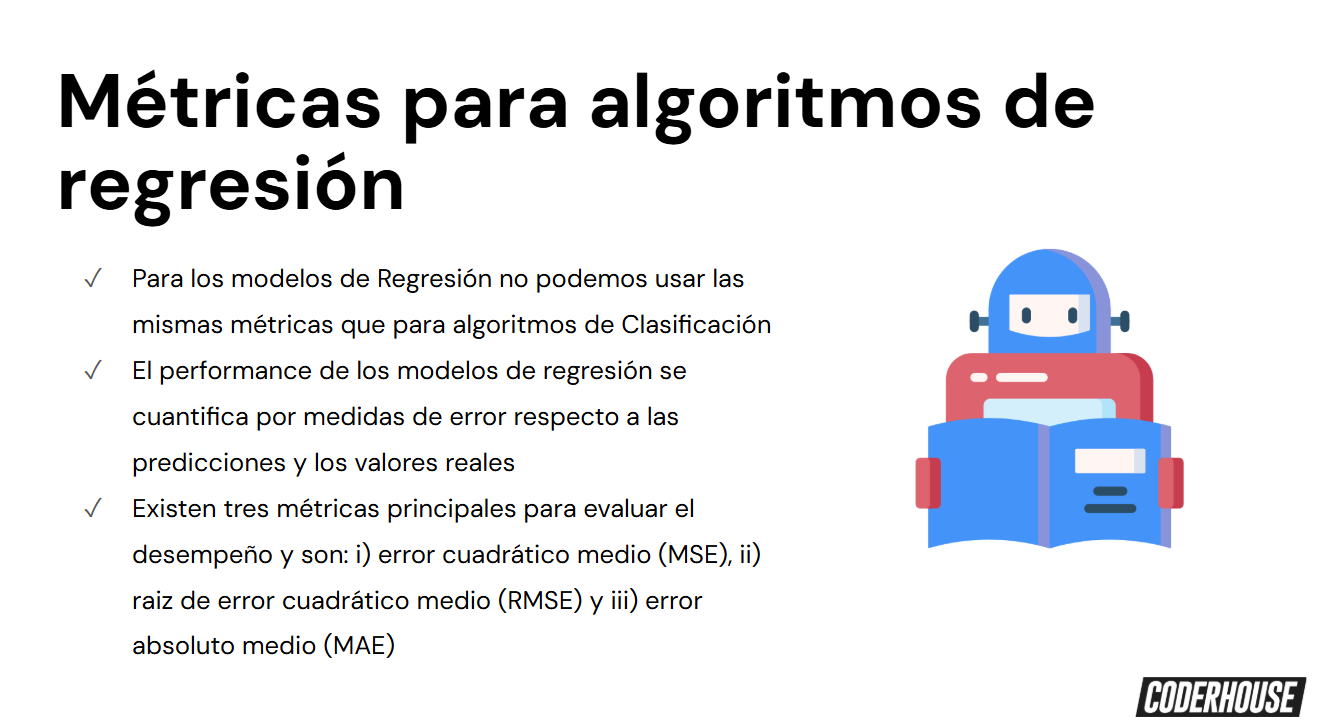

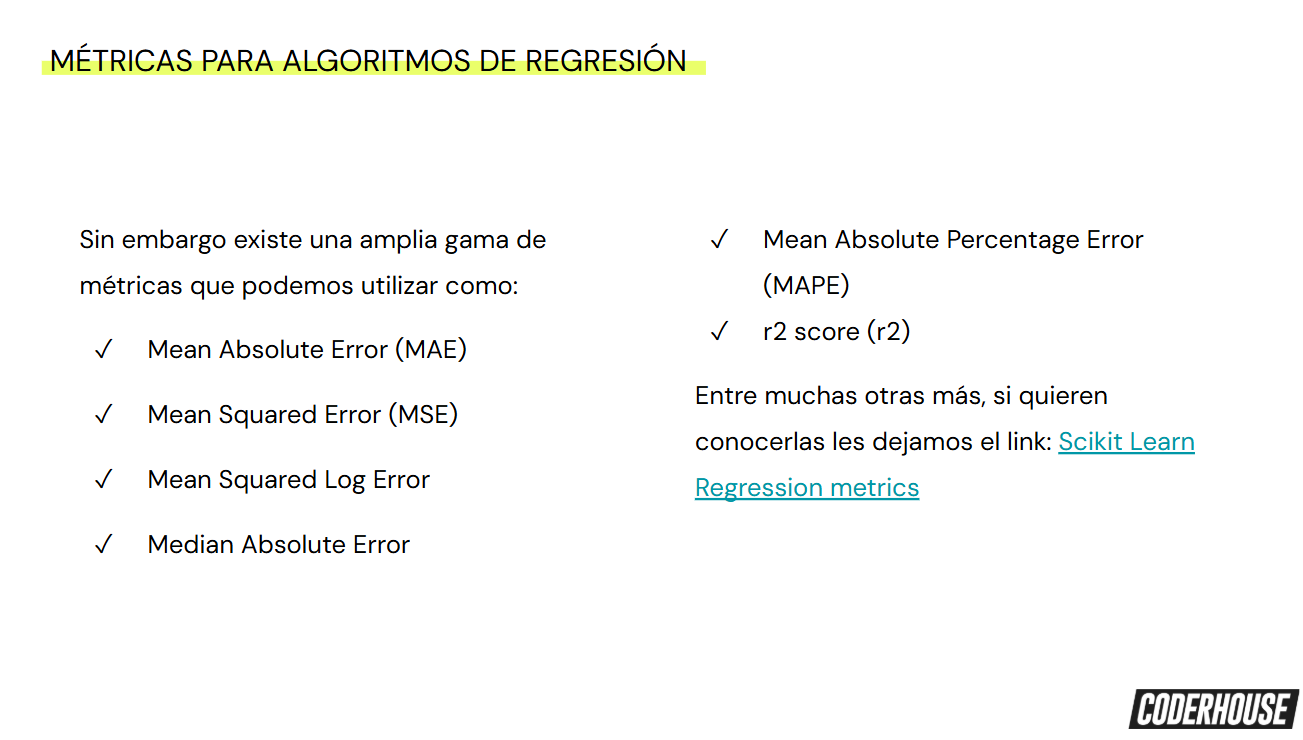

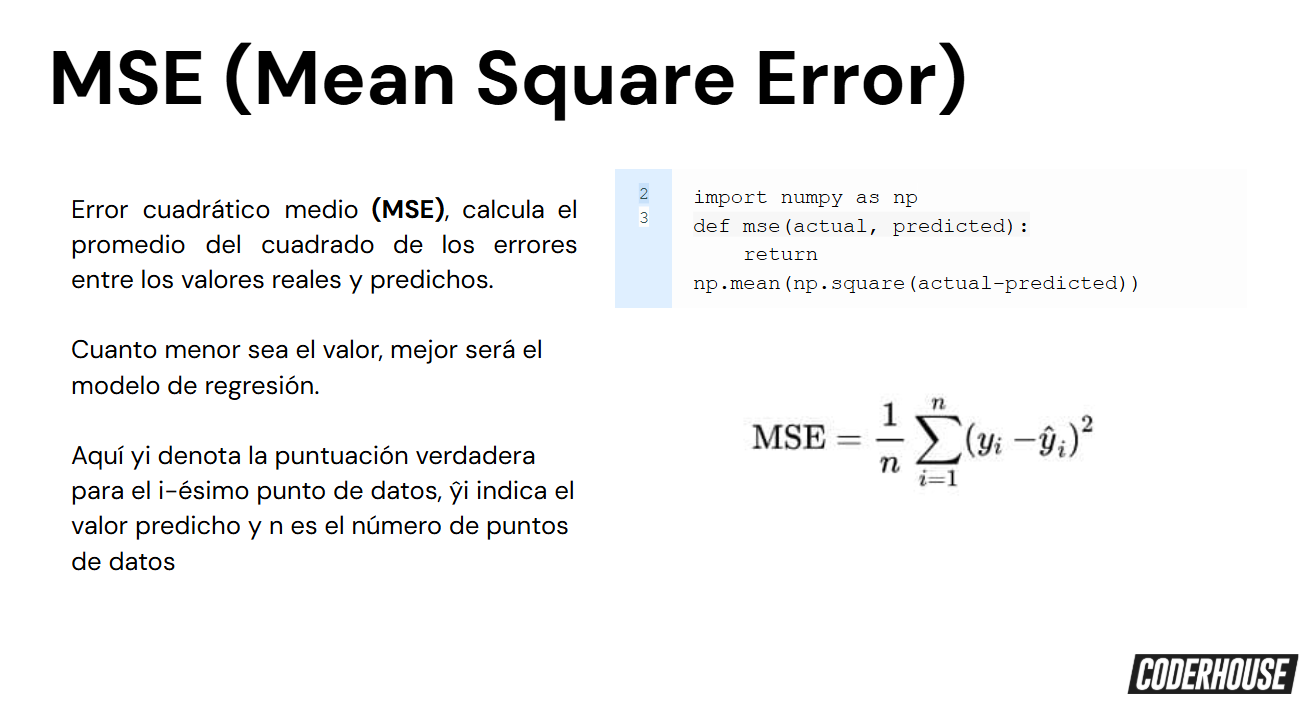

# Para calcularlo:

Restás el valor real menos el valor predicho → eso te da el error.

Lo elevás al cuadrado (para que no se cancelen positivos con negativos).

Sumás todos esos errores cuadrados.

Dividís por la cantidad de datos.

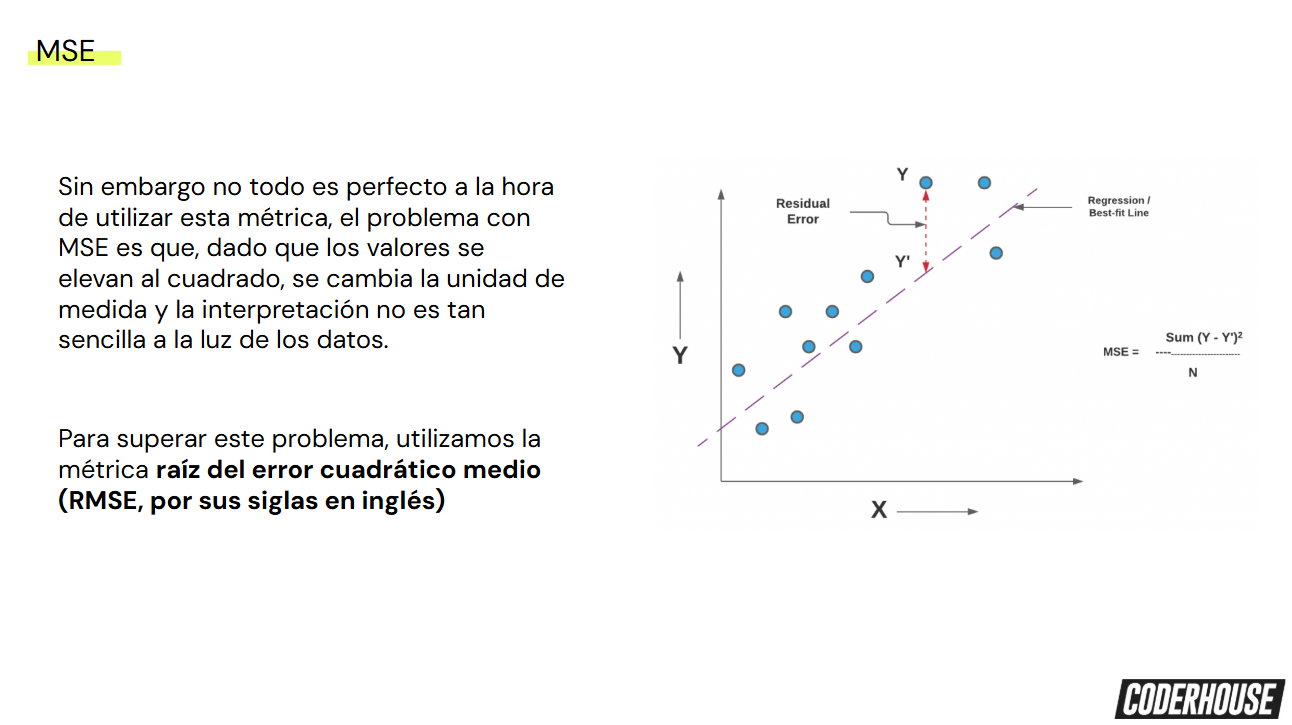

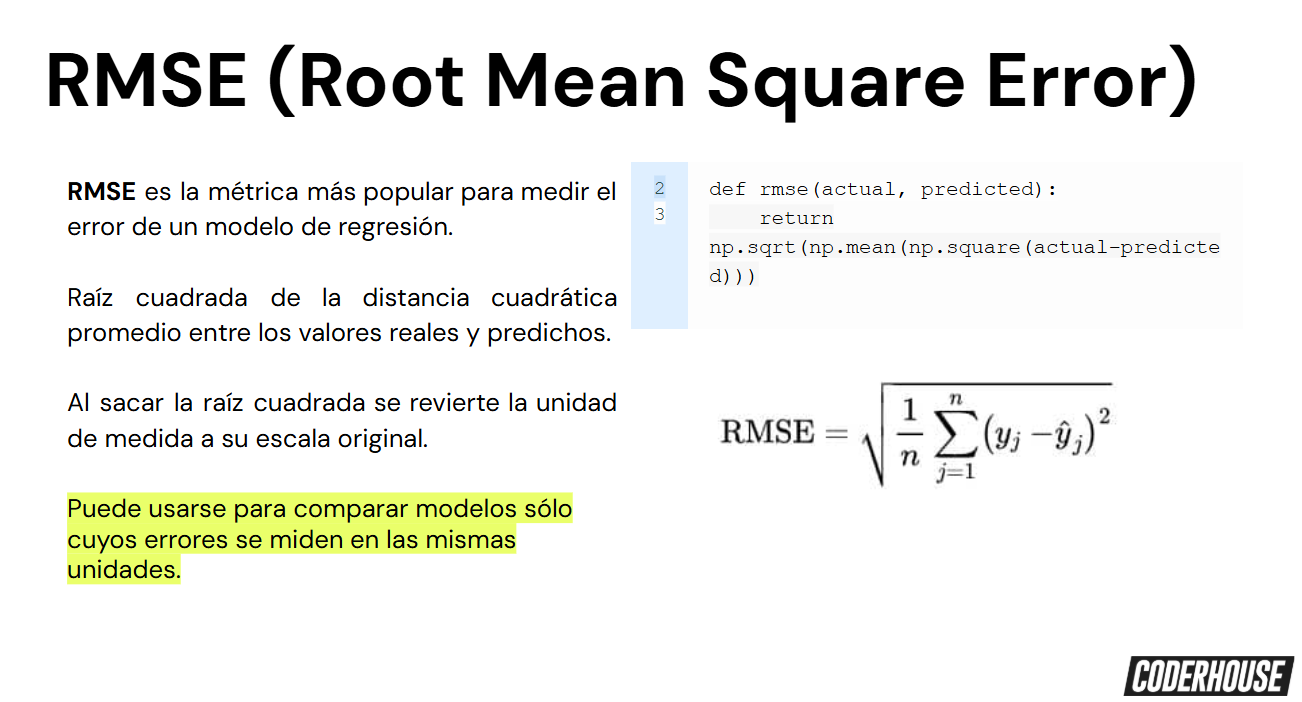

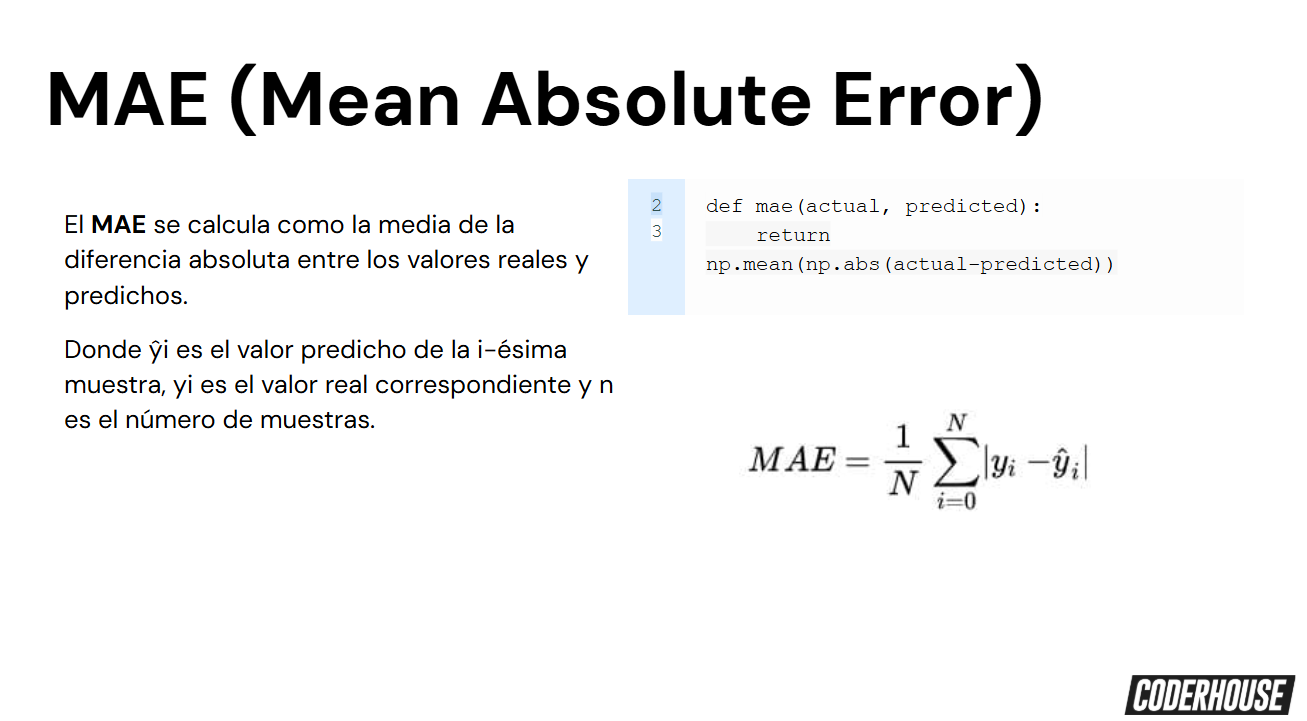

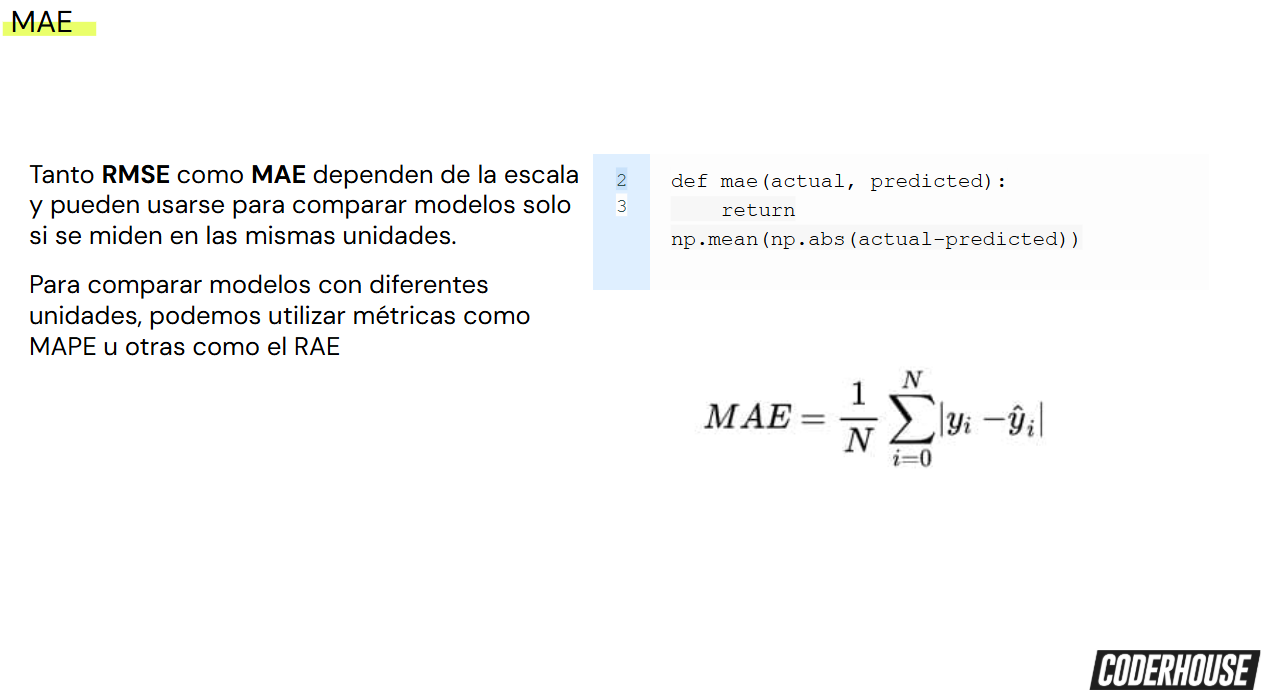

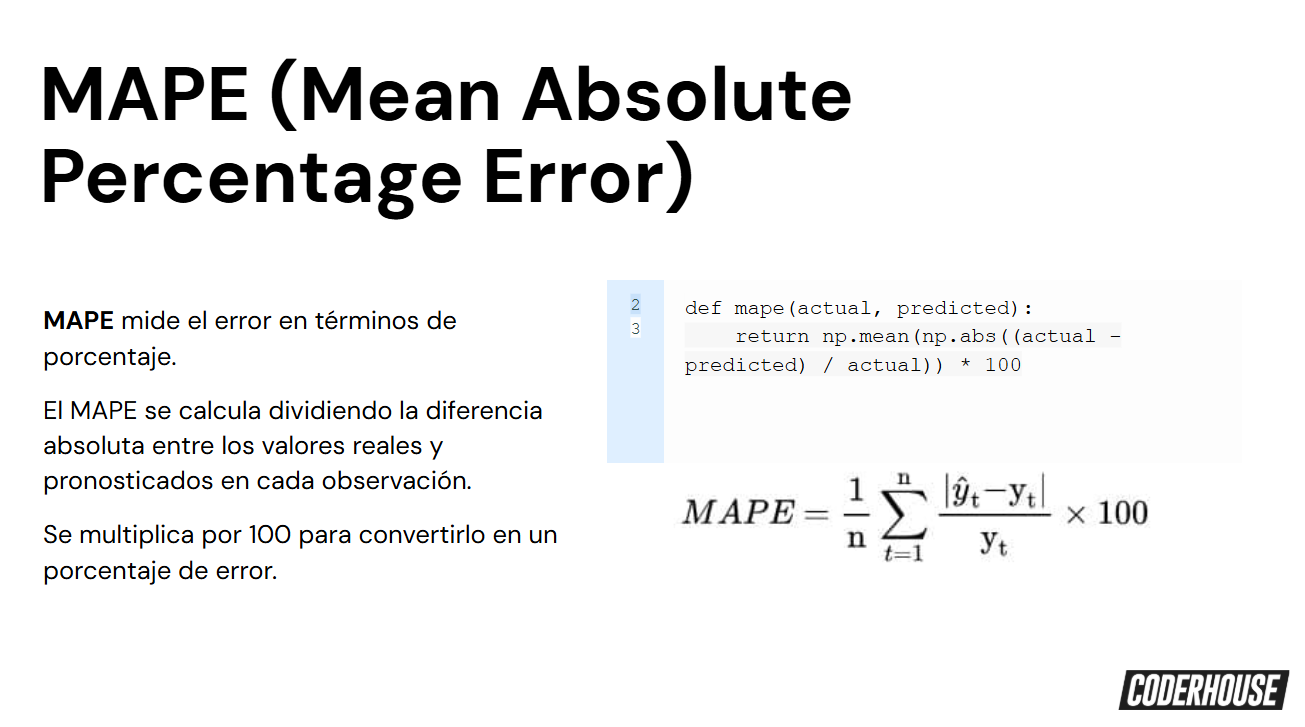

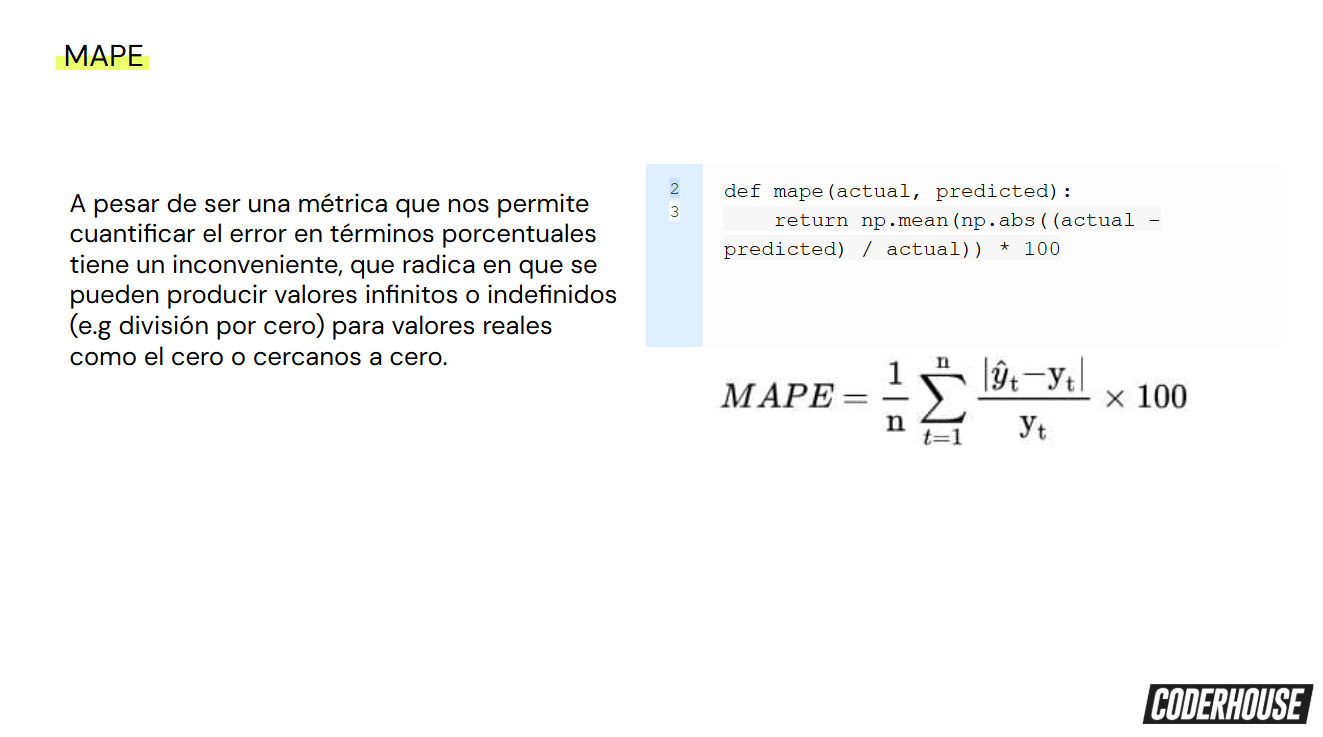

El MAPE (Mean Absolute Percentage Error) te dice cuánto se equivocó tu modelo en promedio, expresado en porcentaje.

🧾 ¿Cómo se calcula?
Tomás la diferencia entre el valor real y el valor predicho (el error).

La convertís en valor absoluto (sin importar si es positivo o negativo).

Dividís ese error por el valor real → así sabés qué porcentaje representa ese error.

Promediás todos esos porcentajes.

Y finalmente, multiplicás por 100 para tener un número en porcentaje.



No se puede usar si algún valor real es 0, porque no se puede dividir por cero.

Es muy útil para presentar resultados a personas no técnicas.



In [ ]:
import numpy as np

# Valores reales y predichos
y_real = np.array([100, 200, 300])
y_pred = np.array([90, 180, 330])

# Cálculo del MAPE
def calcular_mape(y_real, y_pred):
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    return mape

# Resultado
mape_resultado = calcular_mape(y_real, y_pred)
print(f"MAPE: {mape_resultado:.2f}%")


MAPE: 10.00%


El modelo se equivoca en promedio un 10% respecto al valor real. Es una forma muy clara de comunicar el error en regresión, sobre todo para audiencias no técnicas.

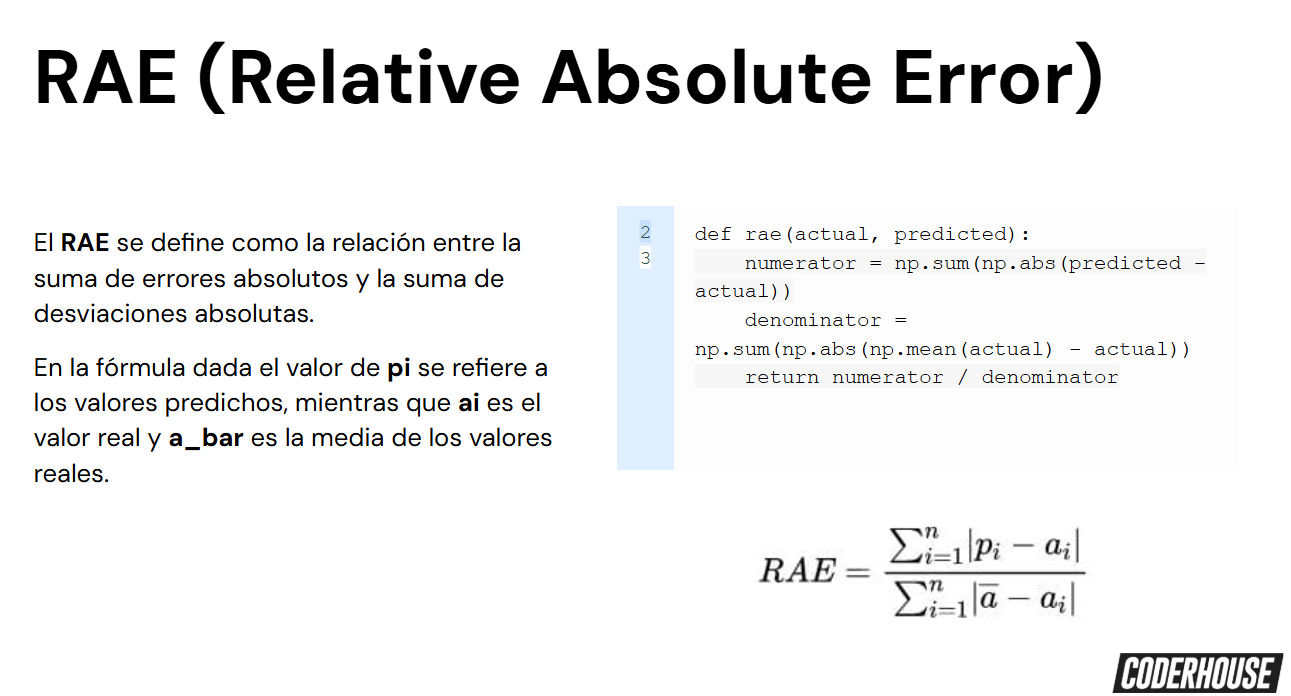

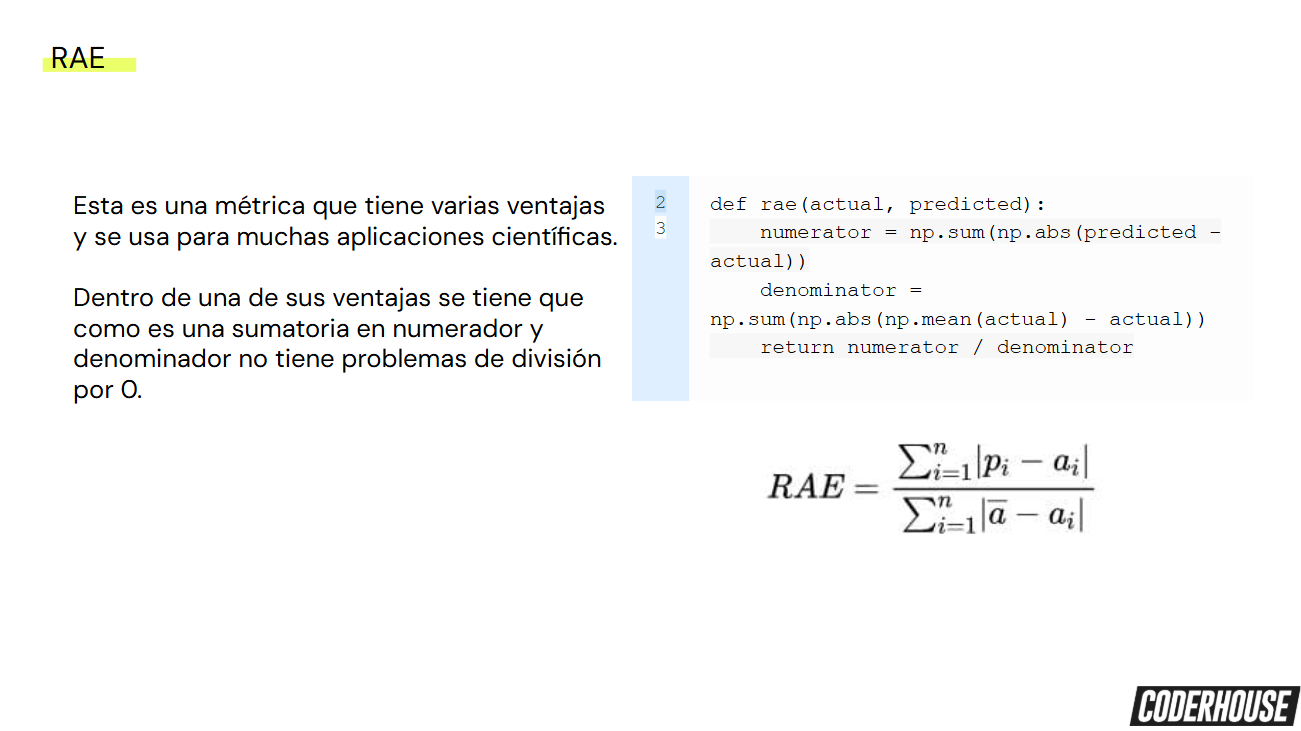

| Valor de RAE | ¿Qué significa?                                           |
| ------------ | --------------------------------------------------------- |
| = 1          | Tu modelo predice igual que usar el promedio. 🤷‍♀️       |
| < 1          | Tu modelo es **mejor** que usar el promedio. ✅            |
| > 1          | Tu modelo es **peor** que simplemente usar el promedio. ❌ |


RAE te dice si tu modelo vale la pena o no, comparado con un modelo básico que siempre dice lo mismo (el promedio).



In [ ]:
import numpy as np

# Valores reales y predichos
y_real = np.array([100, 200, 300])
y_pred = np.array([110, 190, 280])

# Paso 1: calcular el promedio de los valores reales
y_promedio = np.mean(y_real)

# Paso 2: calcular el numerador (error absoluto del modelo)
error_modelo = np.sum(np.abs(y_real - y_pred))

# Paso 3: calcular el denominador (error absoluto usando el promedio)
error_promedio = np.sum(np.abs(y_real - y_promedio))

# Paso 4: calcular el RAE
rae = error_modelo / error_promedio

# Resultado
print(f"RAE: {rae:.2f}")


RAE: 0.20


Un RAE menor que 1 (como el caso: 0.20) indica que el modelo es mejor que usar el promedio.
Cuanto más cercano a 0, mejor es el modelo.
Mi modelo reduce el error en un 80% comparado con simplemente predecir el promedio. Es mucho más efectivo que una estrategia básica.

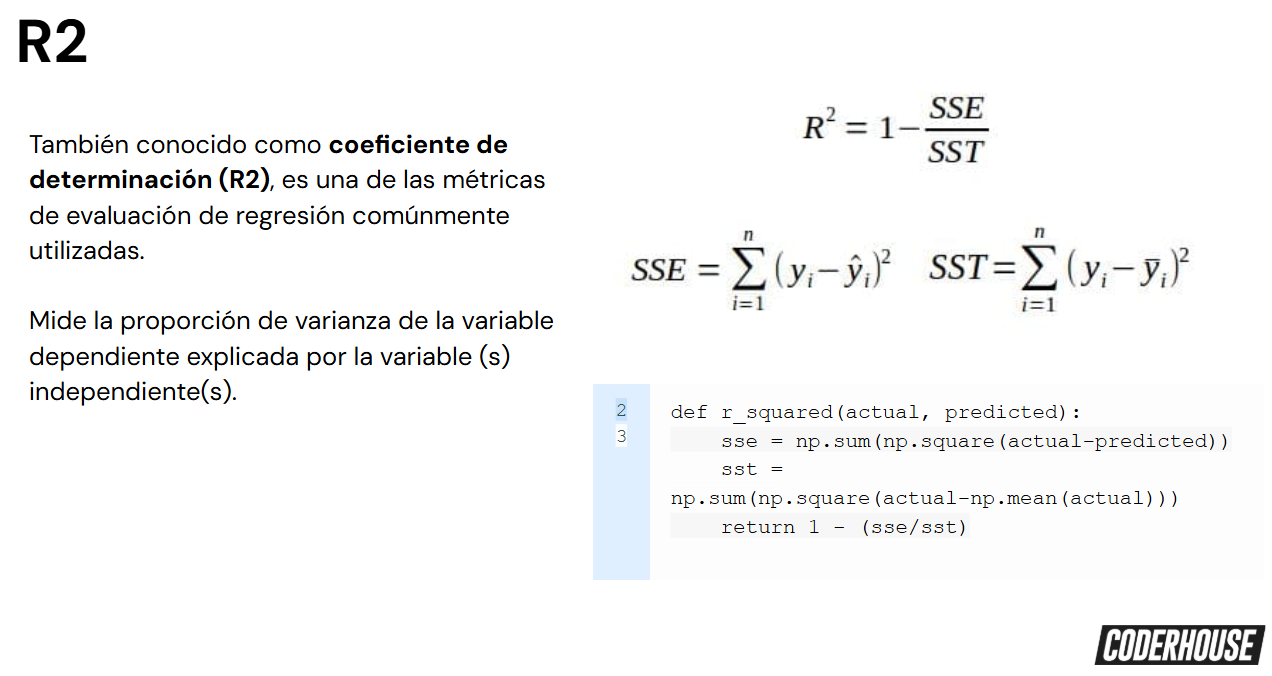

El R² mide cuánto del cambio en Y (la variable dependiente) puede ser explicado por X (las variables independientes) usando tu modelo.

| R²   | Interpretación                    |
| ---- | --------------------------------- |
| 1    | Predice perfectamente 🧠          |
| 0.90 | Explica el 90% de la variación ✔️ |
| 0.50 | Explica el 50% de la variación 😐 |
| 0    | No explica nada ❌                 |
| < 0  | Peor que adivinar con la media 😱 |


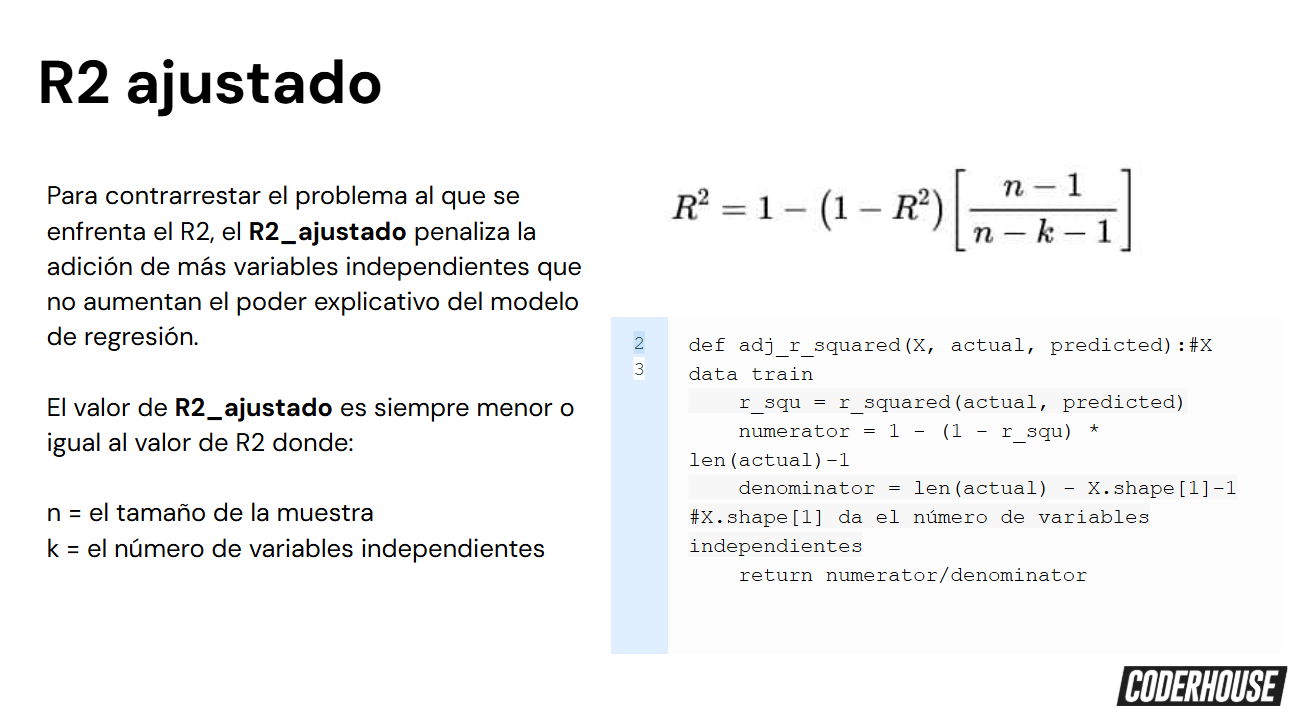

El R² ajustado es una versión mejorada del R² que corrige el entusiasmo del R² cuando agregás muchas variables.

¿Por qué necesitamos el R² ajustado?
Porque el R² normal siempre sube o se mantiene al agregar variables, incluso si son irrelevantes.
El R² ajustado baja si las nuevas variables no aportan valor real.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Datos de ejemplo
X = pd.DataFrame({
    "horas_estudio": [1, 2, 3, 4, 5, 6],
    "horas_sueno":   [8, 7, 6, 5, 4, 3]
})
y = np.array([50, 55, 65, 70, 75, 80])  # nota en el examen

# Entrenar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Predicciones
y_pred = modelo.predict(X)

# R² normal
r2 = r2_score(y, y_pred)

# R² ajustado
n = X.shape[0]  # cantidad de observaciones
k = X.shape[1]  # cantidad de variables independientes

r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - k - 1)

# Mostrar resultados
print(f"R²: {r2:.4f}")
print(f"R² ajustado: {r2_ajustado:.4f}")



R²: 0.9844
R² ajustado: 0.9740


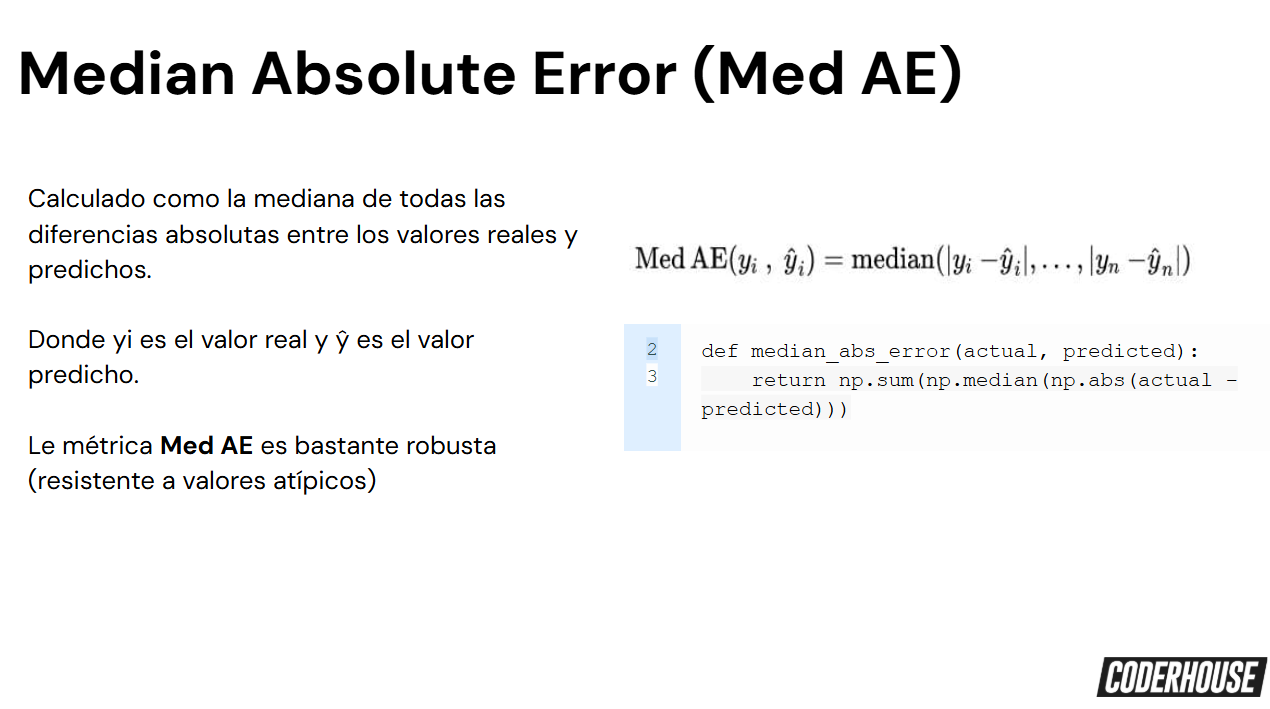

- El Median Absolute Error es la mediana de los errores absolutos entre los valores reales y los valores predichos.

-Como usa la mediana, es muy robusto ante outliers (a diferencia del MAE o RMSE que se ven muy afectados por ellos).



In [ ]:
import numpy as np

def median_abs_error(actual, predicted):
    return np.median(np.abs(actual - predicted))


In [ ]:
actual = np.array([100, 200, 300, 400, 1000])
predicted = np.array([110, 190, 290, 405, 800])

med_ae = median_abs_error(actual, predicted)
print(f"Median Absolute Error: {med_ae}")

#En promedio, tu modelo se equivoca alrededor de 10 unidades en sus predicciones más representativas (excluyendo extremos).

Median Absolute Error: 10.0


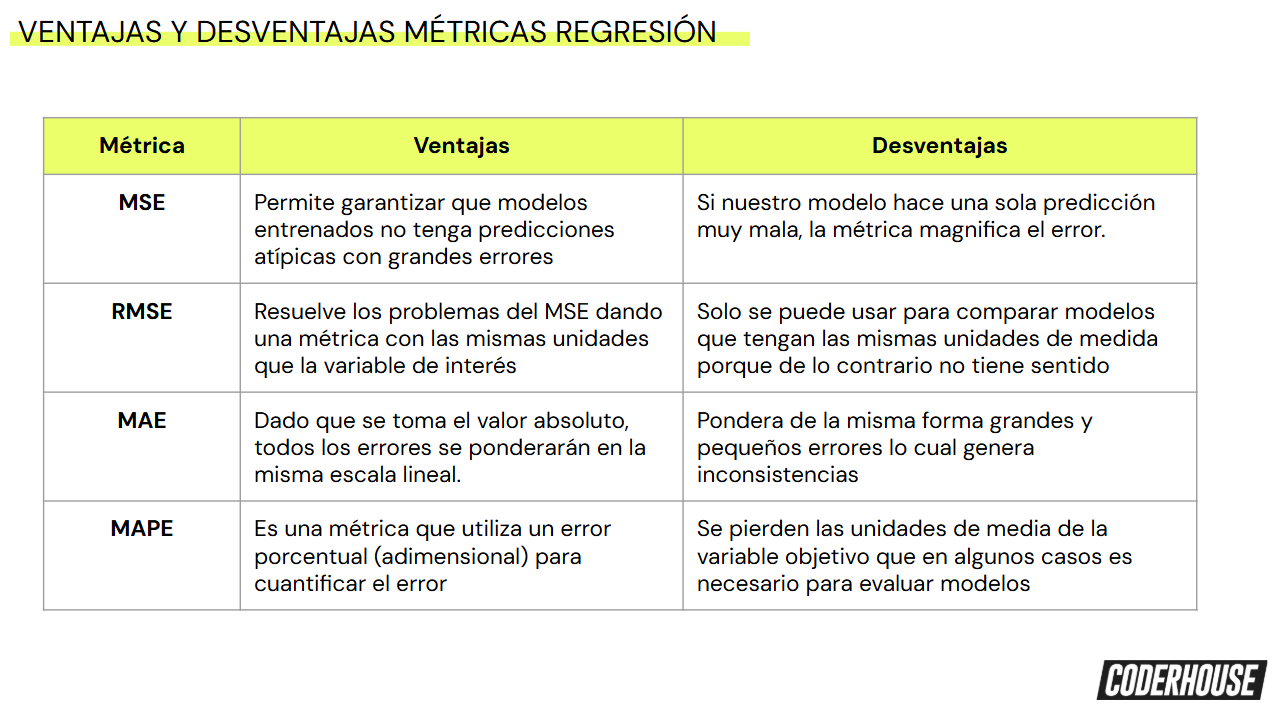

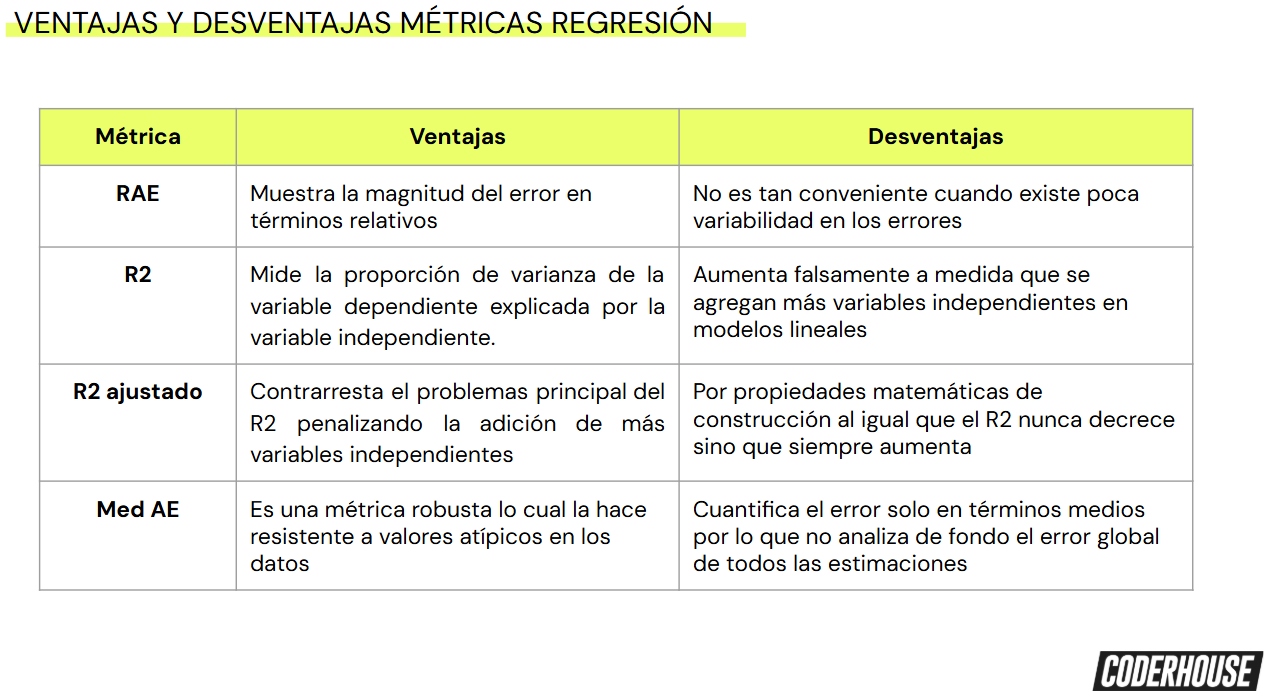